In [6]:
import os
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ethon0426/lending-club-20072020q1")

def get_folder_size(folder_path):
    total_size = 0
    for dirpath, dirnames, filenames in os.walk(folder_path):
        for f in filenames:
            fp = os.path.join(dirpath, f)
            if os.path.isfile(fp):
                total_size += os.path.getsize(fp)
    return total_size

size_bytes = get_folder_size(path)
size_gb = size_bytes / (1024 ** 3)
print(f"Dataset size: {size_gb:.2f} GB")
print("Path to dataset files:", path)


Dataset size: 1.65 GB
Path to dataset files: /Users/clarencemarvin/.cache/kagglehub/datasets/ethon0426/lending-club-20072020q1/versions/3


In [7]:
import os
import pandas as pd

path = "/Users/clarencemarvin/.cache/kagglehub/datasets/ethon0426/lending-club-20072020q1/versions/3"

# List files in the directory
files = os.listdir(path)
print(files)


['LCDataDictionary.xlsx', 'Loan_status_2007-2020Q3.gzip']


In [357]:
import warnings
warnings.filterwarnings("ignore")

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
import shap
from scipy import sparse

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 42
N_TRIALS = 50

file_path = "/Users/clarencemarvin/Desktop/past paper/COMP3355/COMP4501/Loan_status_2007-2020Q3 2.csv"
df = pd.read_csv(file_path, low_memory=False)

In [358]:
# Recreate default if needed
if "default" not in df.columns:
    status_map = {
        'Fully Paid': 0,
        'Does not meet the credit policy. Status:Fully Paid': 0,
        'Charged Off': 1,
        'Does not meet the credit policy. Status:Charged Off': 1,
        'Default': 1
    }
    df["default"] = df["loan_status"].map(status_map)

# Parse issue date
df["issue_d_parsed"] = pd.to_datetime(df["issue_d"], format="%b-%y", errors="coerce")
df["issue_year"] = df["issue_d_parsed"].dt.year

# Helper functions
def percent_to_float(series):
    if series.dtype == "object":
        return pd.to_numeric(
            series.astype(str).str.replace("%", "", regex=False).str.strip(),
            errors="coerce"
        )
    return pd.to_numeric(series, errors="coerce")

def emp_length_to_num(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    if x == "< 1 year":
        return 0
    if x == "10+ years":
        return 10
    match = re.search(r"(\d+)", x)
    return float(match.group(1)) if match else np.nan

# Clean variables
df["int_rate"] = percent_to_float(df["int_rate"])
df["revol_util"] = percent_to_float(df["revol_util"])
df["dti"] = pd.to_numeric(df["dti"], errors="coerce")
df["annual_inc"] = pd.to_numeric(df["annual_inc"], errors="coerce")
df["fico_range_low"] = pd.to_numeric(df["fico_range_low"], errors="coerce")
df["loan_amnt"] = pd.to_numeric(df["loan_amnt"], errors="coerce")
df["emp_length_num"] = df["emp_length"].apply(emp_length_to_num)

selected_features = [
    "term",
    "fico_range_low",
    "loan_amnt",
    "dti",
    "home_ownership",
    "purpose",
    "revol_util",
    "annual_inc",
    "emp_length",
    "open_acc",
    "delinq_2yrs",
    "pub_rec",
    "inq_last_6mths",
    "mort_acc",
    "revol_bal"
]

required_cols = selected_features + ["default", "issue_d", "issue_d_parsed", "issue_year"]
df_model = df[required_cols].copy()

# Keep only rows with mapped default and valid year
df_model = df_model.dropna(subset=["default", "issue_d_parsed"])
df_model["default"] = df_model["default"].astype(int)

print("Shape of modeling data:", df_model.shape)
print("\nAvailable years:")
print(df_model["issue_year"].value_counts().sort_index())

print("\nDefault rate by year:")
print(
    df_model.groupby("issue_year")["default"]
    .agg(["count", "mean"])
    .rename(columns={"count": "n_obs", "mean": "default_rate"})
)

Shape of modeling data: (591329, 19)

Available years:
issue_year
2007.0       603
2008.0      2393
2009.0      5281
2010.0     12537
2011.0     21721
2012.0     53367
2013.0    134814
2017.0    144906
2018.0    197178
2019.0     18529
Name: count, dtype: int64

Default rate by year:
             n_obs  default_rate
issue_year                      
2007.0         603      0.262023
2008.0        2393      0.207271
2009.0        5281      0.136906
2010.0       12537      0.140145
2011.0       21721      0.151789
2012.0       53367      0.161973
2013.0      134814      0.155970
2017.0      144906      0.236836
2018.0      197178      0.239515
2019.0       18529      0.213719


In [359]:
main_oot_years = [2019]
stress_years = [2008]
train_valid_years = [2007, 2009, 2010, 2011, 2012, 2013, 2017, 2018]

main_oot_df = df_model[df_model["issue_year"].isin(main_oot_years)].copy()
stress_df = df_model[df_model["issue_year"].isin(stress_years)].copy()
train_valid_df = df_model[df_model["issue_year"].isin(train_valid_years)].copy()

train_df, valid_df = train_test_split(
    train_valid_df,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=train_valid_df["default"]
)

def split_summary(name, data):
    print(
        f"{name:12s} | n = {len(data):>8,d} | "
        f"default rate = {data['default'].mean():.4f} | "
        f"years = {sorted(data['issue_year'].unique().tolist())}"
    )

print("Split summary")
split_summary("Train", train_df)
split_summary("Valid", valid_df)
split_summary("OOT_2019", main_oot_df)
split_summary("Stress_2008", stress_df)

Split summary
Train        | n =  456,325 | default rate = 0.2054 | years = [2007.0, 2009.0, 2010.0, 2011.0, 2012.0, 2013.0, 2017.0, 2018.0]
Valid        | n =  114,082 | default rate = 0.2054 | years = [2007.0, 2009.0, 2010.0, 2011.0, 2012.0, 2013.0, 2017.0, 2018.0]
OOT_2019     | n =   18,529 | default rate = 0.2137 | years = [2019.0]
Stress_2008  | n =    2,393 | default rate = 0.2073 | years = [2008.0]


In [360]:
# categorical and numerical columns from df
cat_cols = df_model.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
num_cols = df_model.select_dtypes(include=["number"]).columns.tolist()

print("Categorical columns:")
print(cat_cols)
print("\nNumerical columns:")
print(num_cols)

Categorical columns:
['term', 'home_ownership', 'purpose', 'emp_length', 'issue_d']

Numerical columns:
['fico_range_low', 'loan_amnt', 'dti', 'revol_util', 'annual_inc', 'open_acc', 'delinq_2yrs', 'pub_rec', 'inq_last_6mths', 'mort_acc', 'revol_bal', 'default', 'issue_year']


In [365]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

cat_cols = ['term', 'home_ownership', 'purpose', 'emp_length']
num_cols = [
    'fico_range_low', 'loan_amnt', 'dti', 'revol_util', 'annual_inc',
    'open_acc', 'delinq_2yrs', 'pub_rec',
    'inq_last_6mths', 'mort_acc', 'revol_bal'
]

# keep only columns that exist
cat_cols = [c for c in cat_cols if c in train_df.columns]
num_cols = [c for c in num_cols if c in train_df.columns]
feature_cols = cat_cols + num_cols

# ============================================================
# A. XGB / LGBM preprocessing
# - leave missing as NaN
# - no imputation
# ============================================================
xgb_lgbm_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="infrequent_if_exist",
                min_frequency=50,
                sparse_output=True
            ),
            cat_cols
        )
    ],
    remainder="drop"
)

X_train_xgb_lgbm = xgb_lgbm_preprocessor.fit_transform(train_df[feature_cols])
X_valid_xgb_lgbm = xgb_lgbm_preprocessor.transform(valid_df[feature_cols])
X_oot_xgb_lgbm = xgb_lgbm_preprocessor.transform(main_oot_df[feature_cols])
X_stress_xgb_lgbm = xgb_lgbm_preprocessor.transform(stress_df[feature_cols])

# ============================================================
# B. RF preprocessing
# - drop rows with NA in selected features
# - no imputation
# ============================================================
# RF: drop rows with NA, but exclude mort_acc since it is 100% missing in stress
rf_feature_cols = [c for c in feature_cols if c != "mort_acc"]

rf_train_df = train_df.dropna(subset=rf_feature_cols).copy()
rf_valid_df = valid_df.dropna(subset=rf_feature_cols).copy()
rf_oot_df = main_oot_df.dropna(subset=rf_feature_cols).copy()
rf_stress_df = stress_df.dropna(subset=rf_feature_cols).copy()

print("RF feature cols:", rf_feature_cols)
print("RF rows left:")
print("train:", len(rf_train_df))
print("valid:", len(rf_valid_df))
print("oot:", len(rf_oot_df))
print("stress:", len(rf_stress_df))

y_train_rf = rf_train_df["default"]
y_valid_rf = rf_valid_df["default"]
y_oot_rf = rf_oot_df["default"]
y_stress_rf = rf_stress_df["default"]

rf_cat_cols = [c for c in cat_cols if c in rf_feature_cols]
rf_num_cols = [c for c in num_cols if c in rf_feature_cols]

rf_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", rf_num_cols),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="infrequent_if_exist",
                min_frequency=50,
                sparse_output=True
            ),
            rf_cat_cols
        )
    ],
    remainder="drop"
)

X_train_rf = rf_preprocessor.fit_transform(rf_train_df[rf_feature_cols])
X_valid_rf = rf_preprocessor.transform(rf_valid_df[rf_feature_cols])
X_oot_rf = rf_preprocessor.transform(rf_oot_df[rf_feature_cols])
X_stress_rf = rf_preprocessor.transform(rf_stress_df[rf_feature_cols])

print("XGB/LGBM train shape:", X_train_xgb_lgbm.shape)
print("RF train shape:", X_train_rf.shape)
print("XGB/LGBM train shape:", X_train_xgb_lgbm.shape)
print("RF train shape:", X_train_rf.shape)
print("RF dropped rows in train:", len(train_df) - len(rf_train_df))
print("RF dropped rows in valid:", len(valid_df) - len(rf_valid_df))
print("RF dropped rows in oot:", len(main_oot_df) - len(rf_oot_df))
print("RF dropped rows in stress:", len(stress_df) - len(rf_stress_df))

RF feature cols: ['term', 'home_ownership', 'purpose', 'emp_length', 'fico_range_low', 'loan_amnt', 'dti', 'revol_util', 'annual_inc', 'open_acc', 'delinq_2yrs', 'pub_rec', 'inq_last_6mths', 'revol_bal']
RF rows left:
train: 426474
valid: 106631
oot: 16602
stress: 2381
XGB/LGBM train shape: (456325, 45)
RF train shape: (426474, 43)
XGB/LGBM train shape: (456325, 45)
RF train shape: (426474, 43)
RF dropped rows in train: 29851
RF dropped rows in valid: 7451
RF dropped rows in oot: 1927
RF dropped rows in stress: 12


In [366]:
def auc_score(y_true, y_prob):
    return roc_auc_score(y_true, y_prob)

def gini_score(y_true, y_prob):
    return 2 * roc_auc_score(y_true, y_prob) - 1

def ks_statistic(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    ks_values = tpr - fpr
    best_idx = np.argmax(ks_values)
    best_threshold = thresholds[best_idx]

    # avoid inf threshold edge case
    if not np.isfinite(best_threshold):
        finite_mask = np.isfinite(thresholds)
        thresholds = thresholds[finite_mask]
        ks_values = ks_values[finite_mask]
        best_idx = np.argmax(ks_values)
        best_threshold = thresholds[best_idx]

    return ks_values[best_idx], best_threshold

def evaluate_split(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)

    return {
        "AUC": auc_score(y_true, y_prob),
        "Gini": gini_score(y_true, y_prob),
        "KS": ks_statistic(y_true, y_prob)[0],
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0)
    }

def build_prediction_table(base_df, y_true, y_prob, threshold, model_name, split_name):
    pred_label = (y_prob >= threshold).astype(int)

    out = pd.DataFrame({
        "issue_d": base_df.loc[y_true.index, "issue_d"].values,
        "issue_year": base_df.loc[y_true.index, "issue_year"].values,
        "actual_default": y_true.values,
        "pred_label": pred_label,
        "prob_non_default": 1 - y_prob,
        "prob_default": y_prob,
        "model": model_name,
        "split": split_name
    }, index=y_true.index)

    return out

def plot_confusion(y_true, y_pred, title):
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred, ax=ax, colorbar=False)
    ax.set_title(title)
    plt.show()

# class ratio for optional weighting
pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
print("Negative / Positive ratio in training set:", round(pos_weight, 4))

Negative / Positive ratio in training set: 3.869


In [367]:
def calculate_psi(expected, actual, buckets=10, eps=1e-6):
    """
    expected: reference scores/probabilities
    actual: comparison scores/probabilities
    """
    expected = pd.Series(expected).dropna().astype(float)
    actual = pd.Series(actual).dropna().astype(float)

    breakpoints = np.unique(np.quantile(expected, np.linspace(0, 1, buckets + 1)))
    if len(breakpoints) < 3:
        return np.nan

    expected_bins = pd.cut(expected, bins=breakpoints, include_lowest=True)
    actual_bins = pd.cut(actual, bins=breakpoints, include_lowest=True)

    expected_dist = expected_bins.value_counts(normalize=True, sort=False) + eps
    actual_dist = actual_bins.value_counts(normalize=True, sort=False) + eps

    psi = ((actual_dist - expected_dist) * np.log(actual_dist / expected_dist)).sum()
    return float(psi)

def year_to_year_psi(pred_df, score_col="prob_default"):
    """
    pred_df must contain issue_year and score_col
    computes PSI for consecutive years
    """
    tmp = pred_df.dropna(subset=["issue_year", score_col]).copy()
    tmp["issue_year"] = tmp["issue_year"].astype(int)

    years = sorted(tmp["issue_year"].unique().tolist())
    rows = []

    for y1, y2 in zip(years[:-1], years[1:]):
        s1 = tmp.loc[tmp["issue_year"] == y1, score_col]
        s2 = tmp.loc[tmp["issue_year"] == y2, score_col]
        psi_val = calculate_psi(s1, s2, buckets=10)

        rows.append({
            "Year_1": y1,
            "Year_2": y2,
            "PSI": psi_val
        })

    return pd.DataFrame(rows)

In [368]:
def xgb_objective(trial):
    reg_alpha = trial.suggest_float("reg_alpha", 2.5, 5.0)
    reg_lambda = trial.suggest_float("reg_lambda", 2.5, 5.0)

    params = {
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 0.85),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "n_estimators": trial.suggest_int("n_estimators", 100, 200),
        "reg_alpha": reg_alpha,
        "reg_lambda": reg_lambda,
        "objective": "binary:logistic",
        "eval_metric": "auc",
        "random_state": 42,
        "verbosity": 0,
        "n_jobs": -1
    }

    model = XGBClassifier(**params)
    model.fit(X_train_xgb_lgbm, y_train)

    valid_prob = model.predict_proba(X_valid_xgb_lgbm)[:, 1]
    return gini_score(y_valid, valid_prob)


def lgbm_objective(trial):
    reg_alpha = trial.suggest_float("reg_alpha", 2.5, 5.0)
    reg_lambda = trial.suggest_float("reg_lambda", 2.5, 5.0)

    params = {
        "num_leaves": trial.suggest_int("num_leaves", 31, 150),
        "min_child_samples": trial.suggest_int("min_child_samples", 15, 35),
        "feature_fraction": trial.suggest_float("feature_fraction", 0.7, 1.0),
        "n_estimators": trial.suggest_int("n_estimators", 100, 300),
        "learning_rate": trial.suggest_float("learning_rate", 0.05, 0.2),
        "max_depth": trial.suggest_int("max_depth", 5, 7),
        "reg_alpha": reg_alpha,
        "reg_lambda": reg_lambda,
        "objective": "binary",
        "random_state": 42,
        "verbosity": -1
    }

    model = LGBMClassifier(**params)
    model.fit(X_train_xgb_lgbm, y_train)

    valid_prob = model.predict_proba(X_valid_xgb_lgbm)[:, 1]
    return gini_score(y_valid, valid_prob)


def rf_objective(trial):
    max_depth_choice = trial.suggest_categorical("max_depth_type", ["int", "none"])
    if max_depth_choice == "none":
        max_depth = None
    else:
        max_depth = trial.suggest_int("max_depth", 4, 12)

    min_samples_split = trial.suggest_int("min_samples_split", 10, 50)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 5, 20)

    max_leaf_nodes_choice = trial.suggest_categorical("max_leaf_nodes_type", ["int", "none"])
    if max_leaf_nodes_choice == "none":
        max_leaf_nodes_val = None
    else:
        max_leaf_nodes_val = trial.suggest_int("max_leaf_nodes", 10, 100)

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 300),
        "max_depth": max_depth,
        "min_samples_split": min_samples_split,
        "min_samples_leaf": min_samples_leaf,
        "max_leaf_nodes": max_leaf_nodes_val,
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        "random_state": 42,
        "n_jobs": -1
    }

    model = RandomForestClassifier(**params)
    model.fit(X_train_rf, y_train_rf)

    valid_prob = model.predict_proba(X_valid_rf)[:, 1]
    return gini_score(y_valid_rf, valid_prob)

In [369]:
def run_optuna_xgb():
    print(f"\n{'='*25}\nTuning XGBoost\n{'='*25}")

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
    )
    study.optimize(xgb_objective, n_trials=N_TRIALS*2, show_progress_bar=True)

    best_params = study.best_params.copy()
    print("Best validation Gini:", round(study.best_value, 6))
    print("Best params:", best_params)

    final_model = XGBClassifier(**best_params, **xgb_fixed)
    final_model.fit(X_train_xgb_lgbm, y_train)
    valid_prob = final_model.predict_proba(X_valid_xgb_lgbm)[:, 1]
    valid_ks, best_threshold = ks_statistic(y_valid, valid_prob)

    print("Validation KS:", round(valid_ks, 6))
    print("Chosen threshold from validation KS:", round(best_threshold, 6))

    return study, final_model, best_threshold


def run_optuna_lgbm():
    print(f"\n{'='*25}\nTuning LightGBM\n{'='*25}")

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
    )
    study.optimize(lgbm_objective, n_trials=N_TRIALS*2, show_progress_bar=True)

    best_params = study.best_params.copy()
    print("Best validation Gini:", round(study.best_value, 6))
    print("Best params:", best_params)

    final_model = LGBMClassifier(**best_params, **lgbm_fixed)
    final_model.fit(X_train_xgb_lgbm, y_train)
    valid_prob = final_model.predict_proba(X_valid_xgb_lgbm)[:, 1]
    valid_ks, best_threshold = ks_statistic(y_valid, valid_prob)

    print("Validation KS:", round(valid_ks, 6))
    print("Chosen threshold from validation KS:", round(best_threshold, 6))

    return study, final_model, best_threshold


def run_optuna_rf():
    print(f"\n{'='*25}\nTuning Random Forest\n{'='*25}")

    rf_trials = max(1, N_TRIALS // 2)

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
    )
    study.optimize(rf_objective, n_trials=rf_trials, show_progress_bar=True)

    best_params = study.best_params.copy()

    max_depth_type = best_params.pop("max_depth_type", None)
    max_leaf_nodes_type = best_params.pop("max_leaf_nodes_type", None)

    if max_depth_type == "none":
        best_params["max_depth"] = None

    if max_leaf_nodes_type == "none":
        best_params["max_leaf_nodes"] = None

    print("Best validation Gini:", round(study.best_value, 6))
    print("Best params:", best_params)

    final_model = RandomForestClassifier(**best_params, **rf_fixed)
    final_model.fit(X_train_rf, y_train_rf)
    valid_prob = final_model.predict_proba(X_valid_rf)[:, 1]
    valid_ks, best_threshold = ks_statistic(y_valid_rf, valid_prob)

    print("Validation KS:", round(valid_ks, 6))
    print("Chosen threshold from validation KS:", round(best_threshold, 6))

    return study, final_model, best_threshold

xgb_fixed = {
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "tree_method": "hist",
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "verbosity": 0
}

lgbm_fixed = {
    "objective": "binary",
    "verbosity": -1,
    "random_state": RANDOM_STATE,
    "n_jobs": -1
}

rf_fixed = {
    "random_state": RANDOM_STATE,
    "n_jobs": -1
}

In [370]:
xgb_study, xgb_model, xgb_threshold = run_optuna_xgb()



Tuning XGBoost


Best trial: 73. Best value: 0.400493: 100%|██████████| 100/100 [09:19<00:00,  5.59s/it]


Best validation Gini: 0.400493
Best params: {'reg_alpha': 3.8908476655465263, 'reg_lambda': 2.808787770724578, 'max_depth': 6, 'min_child_weight': 2, 'subsample': 0.9281569024298968, 'colsample_bytree': 0.7753317327578025, 'learning_rate': 0.14091497577447895, 'n_estimators': 167}
Validation KS: 0.287618
Chosen threshold from validation KS: 0.208539


In [371]:
lgbm_study, lgbm_model, lgbm_threshold = run_optuna_lgbm()



Tuning LightGBM


Best trial: 92. Best value: 0.402206: 100%|██████████| 100/100 [10:28<00:00,  6.29s/it]


Best validation Gini: 0.402206
Best params: {'reg_alpha': 4.848093516790357, 'reg_lambda': 2.961548252151055, 'num_leaves': 31, 'min_child_samples': 26, 'feature_fraction': 0.9428824491136371, 'n_estimators': 289, 'learning_rate': 0.10067276017097597, 'max_depth': 6}
Validation KS: 0.291836
Chosen threshold from validation KS: 0.204566


In [372]:
rf_study, rf_model, rf_threshold = run_optuna_rf()


Tuning Random Forest


Best trial: 21. Best value: 0.375678: 100%|██████████| 25/25 [13:11<00:00, 31.67s/it]


Best validation Gini: 0.375678
Best params: {'min_samples_split': 50, 'min_samples_leaf': 7, 'n_estimators': 219, 'max_features': 'log2', 'max_depth': None, 'max_leaf_nodes': None}
Validation KS: 0.270449
Chosen threshold from validation KS: 0.204178


In [431]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MaxAbsScaler

# ============================================================
# Logistic Regression baseline
# Reuses the RF complete-case data (no NaN, mort_acc excluded)
# MaxAbsScaler preserves sparsity of the OHE matrix
# ============================================================

lr_scaler   = MaxAbsScaler()
X_train_lr  = lr_scaler.fit_transform(X_train_rf)
X_valid_lr  = lr_scaler.transform(X_valid_rf)
X_oot_lr    = lr_scaler.transform(X_oot_rf)
X_stress_lr = lr_scaler.transform(X_stress_rf)

lr_model = LogisticRegression(
    C=0.1,
    max_iter=1000,
    solver="saga",
    random_state=RANDOM_STATE,
    n_jobs=-1
)
lr_model.fit(X_train_lr, y_train_rf)

lr_valid_prob       = lr_model.predict_proba(X_valid_lr)[:, 1]
lr_ks, lr_threshold = ks_statistic(y_valid_rf, lr_valid_prob)

print(f"LR  Validation KS  : {lr_ks:.4f}")
print(f"LR  Threshold      : {lr_threshold:.4f}")
print(f"LR  Validation Gini: {gini_score(y_valid_rf, lr_valid_prob):.4f}")

LR  Validation KS  : 0.2678
LR  Threshold      : 0.1962
LR  Validation Gini: 0.3698


In [433]:
split_map_lr = {
    "valid":       (X_valid_lr,  y_valid_rf,  rf_valid_df),
    "oot_2019":    (X_oot_lr,    y_oot_rf,    rf_oot_df),
    "stress_2008": (X_stress_lr, y_stress_rf, rf_stress_df)
}

models = {
    "LogisticRegression": (lr_model, lr_threshold),
    "XGBoost":            (xgb_model, xgb_threshold),
    "LightGBM":           (lgbm_model, lgbm_threshold),
    "RandomForest":       (rf_model, rf_threshold)
}

split_map_xgb_lgbm = {
    "valid":       (X_valid_xgb_lgbm, y_valid,   valid_df),
    "oot_2019":    (X_oot_xgb_lgbm,   y_oot,     main_oot_df),
    "stress_2008": (X_stress_xgb_lgbm, y_stress, stress_df)
}

split_map_rf = {
    "valid":       (X_valid_rf,  y_valid_rf,  rf_valid_df),
    "oot_2019":    (X_oot_rf,    y_oot_rf,    rf_oot_df),
    "stress_2008": (X_stress_rf, y_stress_rf, rf_stress_df)
}

metrics_rows = []
prediction_tables = {}

for model_name, (model, threshold) in models.items():
    if model_name == "RandomForest":
        split_map = split_map_rf
    elif model_name == "LogisticRegression":
        split_map = split_map_lr
    else:
        split_map = split_map_xgb_lgbm

    for split_name, (X_split, y_split, base_df) in split_map.items():
        prob = model.predict_proba(X_split)[:, 1]
        metrics = evaluate_split(y_split, prob, threshold)

        metrics_rows.append({
            "Model":     model_name,
            "Split":     split_name,
            "Threshold": threshold,
            **metrics
        })

        pred_df = build_prediction_table(
            base_df=base_df,
            y_true=y_split,
            y_prob=prob,
            threshold=threshold,
            model_name=model_name,
            split_name=split_name
        )
        prediction_tables[f"{model_name}_{split_name}"] = pred_df

nonmacro_results_df = pd.DataFrame(metrics_rows).sort_values(
    ["Split", "Gini"], ascending=[True, False]
)
display(nonmacro_results_df)

,Model,Split,Threshold,AUC,Gini,KS,Precision,Recall,F1
7,LightGBM,oot_2019,0.196358,0.688348,0.376697,0.280965,0.305960,0.727273,0.430719
4,XGBoost,oot_2019,0.211212,0.688253,0.376505,0.281161,0.312193,0.691162,0.430109
10,RandomForest,oot_2019,0.209376,0.673476,0.346952,0.256830,0.284714,0.727566,0.409271
1,LogisticRegression,oot_2019,0.196186,0.655478,0.310957,0.226265,0.263923,0.767155,0.392734
5,XGBoost,stress_2008,0.211212,0.668534,0.337069,0.247276,0.297101,0.578629,0.392613
8,LightGBM,stress_2008,0.196358,0.668129,0.336259,0.256580,0.286758,0.633065,0.394720
11,RandomForest,stress_2008,0.209376,0.638203,0.276406,0.192091,0.268799,0.632114,0.377198
2,LogisticRegression,stress_2008,0.196186,0.636101,0.272203,0.198760,0.270973,0.656504,0.383610
6,LightGBM,valid,0.196358,0.712610,0.425221,0.306998,0.318955,0.685118,0.435271
3,XGBoost,valid,0.211212,0.712048,0.424096,0.305005,0.329834,0.642354,0.435863


In [374]:
for name, pred_df in prediction_tables.items():
    save_name = f"{name}_predictions.csv"
    pred_df.to_csv(save_name, index=False)

print("Saved prediction files:")
for name in prediction_tables.keys():
    print(f"- {name}_predictions.csv")

Saved prediction files:
- XGBoost_valid_predictions.csv
- XGBoost_oot_2019_predictions.csv
- XGBoost_stress_2008_predictions.csv
- LightGBM_valid_predictions.csv
- LightGBM_oot_2019_predictions.csv
- LightGBM_stress_2008_predictions.csv
- RandomForest_valid_predictions.csv
- RandomForest_oot_2019_predictions.csv
- RandomForest_stress_2008_predictions.csv


In [375]:
#xgb stacking

In [376]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
import optuna
import numpy as np
import pandas as pd

# --- helpers ---
def get_xgb_best_params():
    params = xgb_study.best_params.copy()
    params.update(xgb_fixed)
    return params

def get_lgbm_best_params():
    params = lgbm_study.best_params.copy()
    params.update(lgbm_fixed)
    return params

def get_rf_best_params():
    params = rf_study.best_params.copy()

    max_depth_type = params.pop("max_depth_type", None)
    max_leaf_nodes_type = params.pop("max_leaf_nodes_type", None)

    if max_depth_type == "none":
        params["max_depth"] = None
    if max_leaf_nodes_type == "none":
        params["max_leaf_nodes"] = None

    params.update(rf_fixed)
    return params

xgb_best_params = get_xgb_best_params()
lgbm_best_params = get_lgbm_best_params()
rf_best_params = get_rf_best_params()

print("Base params ready.")
print("XGB:", xgb_best_params)
print("LGBM:", lgbm_best_params)
print("RF:", rf_best_params)

Base params ready.
XGB: {'reg_alpha': 3.8908476655465263, 'reg_lambda': 2.808787770724578, 'max_depth': 6, 'min_child_weight': 2, 'subsample': 0.9281569024298968, 'colsample_bytree': 0.7753317327578025, 'learning_rate': 0.14091497577447895, 'n_estimators': 167, 'objective': 'binary:logistic', 'eval_metric': 'auc', 'tree_method': 'hist', 'random_state': 42, 'n_jobs': -1, 'verbosity': 0}
LGBM: {'reg_alpha': 4.848093516790357, 'reg_lambda': 2.961548252151055, 'num_leaves': 31, 'min_child_samples': 26, 'feature_fraction': 0.9428824491136371, 'n_estimators': 289, 'learning_rate': 0.10067276017097597, 'max_depth': 6, 'objective': 'binary', 'verbosity': -1, 'random_state': 42, 'n_jobs': -1}
RF: {'min_samples_split': 50, 'min_samples_leaf': 7, 'n_estimators': 219, 'max_features': 'log2', 'max_depth': None, 'max_leaf_nodes': None, 'random_state': 42, 'n_jobs': -1}


In [377]:
# OOF predictions on TRAIN only (XGB + LGBM only)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

n_train = X_train_xgb_lgbm.shape[0]

oof_xgb = np.zeros(n_train)
oof_lgbm = np.zeros(n_train)

for fold, (tr_idx, va_idx) in enumerate(skf.split(X_train_xgb_lgbm, y_train), 1):
    X_tr, X_va = X_train_xgb_lgbm[tr_idx], X_train_xgb_lgbm[va_idx]
    y_tr = y_train.iloc[tr_idx]

    xgb_fold = XGBClassifier(**xgb_best_params)
    lgbm_fold = LGBMClassifier(**lgbm_best_params)

    xgb_fold.fit(X_tr, y_tr)
    lgbm_fold.fit(X_tr, y_tr)

    oof_xgb[va_idx] = xgb_fold.predict_proba(X_va)[:, 1]
    oof_lgbm[va_idx] = lgbm_fold.predict_proba(X_va)[:, 1]

    print(f"Finished fold {fold}/5")

Finished fold 1/5
Finished fold 2/5
Finished fold 3/5
Finished fold 4/5
Finished fold 5/5


In [378]:
# Base-model probabilities on valid / oot / stress
valid_prob_xgb = xgb_model.predict_proba(X_valid_xgb_lgbm)[:, 1]
valid_prob_lgbm = lgbm_model.predict_proba(X_valid_xgb_lgbm)[:, 1]

oot_prob_xgb = xgb_model.predict_proba(X_oot_xgb_lgbm)[:, 1]
oot_prob_lgbm = lgbm_model.predict_proba(X_oot_xgb_lgbm)[:, 1]

stress_prob_xgb = xgb_model.predict_proba(X_stress_xgb_lgbm)[:, 1]
stress_prob_lgbm = lgbm_model.predict_proba(X_stress_xgb_lgbm)[:, 1]

In [379]:
meta_train = pd.DataFrame({
    "prob_xgb": oof_xgb,
    "prob_lgbm": oof_lgbm
}, index=y_train.index)

meta_valid = pd.DataFrame({
    "prob_xgb": valid_prob_xgb,
    "prob_lgbm": valid_prob_lgbm
}, index=y_valid.index)

meta_oot = pd.DataFrame({
    "prob_xgb": oot_prob_xgb,
    "prob_lgbm": oot_prob_lgbm
}, index=y_oot.index)

meta_stress = pd.DataFrame({
    "prob_xgb": stress_prob_xgb,
    "prob_lgbm": stress_prob_lgbm
}, index=y_stress.index)

print(meta_train.shape, meta_valid.shape, meta_oot.shape, meta_stress.shape)

(456325, 2) (114082, 2) (18529, 2) (2393, 2)


In [380]:
def meta_xgb_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 300),
        "max_depth": trial.suggest_int("max_depth", 2, 5),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 5.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "objective": "binary:logistic",
        "eval_metric": "auc",
        "tree_method": "hist",
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
        "verbosity": 0
    }

    model = XGBClassifier(**params)
    model.fit(meta_train, y_train)

    valid_prob = model.predict_proba(meta_valid)[:, 1]
    return gini_score(y_valid, valid_prob)

In [381]:
N_TRIALS_META = 100

meta_study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
meta_study.optimize(meta_xgb_objective, n_trials=N_TRIALS_META, show_progress_bar=True)

meta_best_params = meta_study.best_params.copy()
meta_best_params.update({
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "tree_method": "hist",
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "verbosity": 0
})

print("Best meta validation Gini:", round(meta_study.best_value, 6))
print("Best meta params:", meta_best_params)

Best trial: 61. Best value: 0.402915: 100%|██████████| 100/100 [00:57<00:00,  1.75it/s]

Best meta validation Gini: 0.402915
Best meta params: {'n_estimators': 184, 'max_depth': 2, 'learning_rate': 0.015691357333287477, 'subsample': 0.7160144954044445, 'colsample_bytree': 0.9209823479114614, 'min_child_weight': 1, 'reg_alpha': 0.002212844728902482, 'reg_lambda': 0.1616437627104923, 'objective': 'binary:logistic', 'eval_metric': 'auc', 'tree_method': 'hist', 'random_state': 42, 'n_jobs': -1, 'verbosity': 0}


In [382]:
meta_xgb_model = XGBClassifier(**meta_best_params)
meta_xgb_model.fit(meta_train, y_train)

stack_valid_prob = meta_xgb_model.predict_proba(meta_valid)[:, 1]
stack_oot_prob = meta_xgb_model.predict_proba(meta_oot)[:, 1]
stack_stress_prob = meta_xgb_model.predict_proba(meta_stress)[:, 1]

stack_valid_pred_df = make_pred_df(
    valid_df, y_valid, stack_valid_prob, stack_threshold, "valid", "Stacking_XGB"
)
stack_oot_pred_df = make_pred_df(
    main_oot_df, y_oot, stack_oot_prob, stack_threshold, "oot_2019", "Stacking_XGB"
)
stack_stress_pred_df = make_pred_df(
    stress_df, y_stress, stack_stress_prob, stack_threshold, "stress_2008", "Stacking_XGB"
)

stack_valid_pred_df.to_csv("macro_stacking_xgb_valid_predictions.csv", index=False)
stack_oot_pred_df.to_csv("macro_stacking_xgb_oot_2019_predictions.csv", index=False)
stack_stress_pred_df.to_csv("macro_stacking_xgb_stress_2008_predictions.csv", index=False)

display(stack_valid_pred_df.head())
display(stack_oot_pred_df.head())
display(stack_stress_pred_df.head())

,issue_d,issue_year,actual_default,pred_label,prob_non_default,prob_default,model,split
49220,Dec-13,2013.0,0,0,0.853332,0.146668,Stacking_XGB,valid
441451,Oct-17,2017.0,1,1,0.645717,0.354283,Stacking_XGB,valid
527905,Feb-18,2018.0,0,0,0.842547,0.157453,Stacking_XGB,valid
539507,Feb-18,2018.0,0,1,0.598618,0.401382,Stacking_XGB,valid
191623,Oct-12,2012.0,0,0,0.822991,0.177009,Stacking_XGB,valid


,issue_d,issue_year,actual_default,pred_label,prob_non_default,prob_default,model,split
967317,Mar-19,2019.0,0,0,0.845497,0.154503,Stacking_XGB,oot_2019
967328,Mar-19,2019.0,0,0,0.899925,0.100075,Stacking_XGB,oot_2019
967330,Mar-19,2019.0,1,1,0.659844,0.340156,Stacking_XGB,oot_2019
967339,Mar-19,2019.0,0,1,0.739130,0.260870,Stacking_XGB,oot_2019
967340,Mar-19,2019.0,0,1,0.761857,0.238143,Stacking_XGB,oot_2019


,issue_d,issue_year,actual_default,pred_label,prob_non_default,prob_default,model,split
37968,Dec-08,2008.0,0,0,0.925313,0.074687,Stacking_XGB,stress_2008
37969,Dec-08,2008.0,1,0,0.875401,0.124599,Stacking_XGB,stress_2008
37970,Dec-08,2008.0,0,1,0.745156,0.254844,Stacking_XGB,stress_2008
37972,Dec-08,2008.0,0,0,0.867719,0.132281,Stacking_XGB,stress_2008
37973,Dec-08,2008.0,0,0,0.864689,0.135311,Stacking_XGB,stress_2008


In [383]:
def make_pred_df(base_df, y_true, prob, threshold, split_name, model_name):
    pred = (prob >= threshold).astype(int)
    out = pd.DataFrame({
        "issue_d": base_df["issue_d"].values if "issue_d" in base_df.columns else None,
        "issue_year": base_df["issue_year"].values if "issue_year" in base_df.columns else None,
        "actual_default": y_true.values,
        "pred_label": pred,
        "prob_non_default": 1 - prob,
        "prob_default": prob,
        "model": model_name,
        "split": split_name
    }, index=y_true.index)
    return out

stack_valid_pred_df = make_pred_df(
    valid_df,
    y_valid,
    meta_xgb_model.predict_proba(meta_valid)[:, 1],
    stack_threshold,
    "valid",
    "Stacking_XGB"
)

stack_oot_pred_df = make_pred_df(
    main_oot_df,
    y_oot,
    meta_xgb_model.predict_proba(meta_oot)[:, 1],
    stack_threshold,
    "oot_2019",
    "Stacking_XGB"
)

stack_stress_pred_df = make_pred_df(
    stress_df,
    y_stress,
    meta_xgb_model.predict_proba(meta_stress)[:, 1],
    stack_threshold,
    "stress_2008",
    "Stacking_XGB"
)

stack_valid_pred_df.to_csv("stacking_xgb_valid_predictions.csv", index=False)
stack_oot_pred_df.to_csv("stacking_xgb_oot_2019_predictions.csv", index=False)
stack_stress_pred_df.to_csv("stacking_xgb_stress_2008_predictions.csv", index=False)

print("Saved:")
print("- stacking_xgb_valid_predictions.csv")
print("- stacking_xgb_oot_2019_predictions.csv")
print("- stacking_xgb_stress_2008_predictions.csv")

Saved:
- stacking_xgb_valid_predictions.csv
- stacking_xgb_oot_2019_predictions.csv
- stacking_xgb_stress_2008_predictions.csv


In [384]:
#logistic stacking

In [385]:
from sklearn.linear_model import LogisticRegression

meta_lr_model = LogisticRegression(
    C=1.0,
    penalty="l2",
    solver="lbfgs",
    max_iter=2000,
    random_state=RANDOM_STATE
)

meta_lr_model.fit(meta_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


In [386]:
stack_lr_valid_prob = meta_lr_model.predict_proba(meta_valid)[:, 1]
stack_lr_valid_ks, stack_lr_threshold = ks_statistic(y_valid, stack_lr_valid_prob)

print("Stacking-LR validation Gini:", round(gini_score(y_valid, stack_lr_valid_prob), 6))
print("Stacking-LR validation KS:", round(stack_lr_valid_ks, 6))
print("Chosen threshold:", round(stack_lr_threshold, 6))

Stacking-LR validation Gini: 0.40278
Stacking-LR validation KS: 0.28964
Chosen threshold: 0.188721


In [387]:
stack_lr_results = []

for split_name, X_split, y_split in [
    ("valid", meta_valid, y_valid),
    ("oot_2019", meta_oot, y_oot),
    ("stress_2008", meta_stress, y_stress),
]:
    prob = meta_lr_model.predict_proba(X_split)[:, 1]
    metrics = evaluate_split(y_split, prob, stack_lr_threshold)

    stack_lr_results.append({
        "Model": "Stacking_LR",
        "Split": split_name,
        "Threshold": stack_lr_threshold,
        **metrics
    })

nonmacro_stack_lr_results_df = pd.DataFrame(stack_lr_results)
display(nonmacro_stack_lr_results_df)

,Model,Split,Threshold,AUC,Gini,KS,Precision,Recall,F1
0,Stacking_LR,valid,0.188721,0.701390,0.402780,0.289640,0.321727,0.636465,0.427405
1,Stacking_LR,oot_2019,0.188721,0.681936,0.363872,0.273293,0.317726,0.623737,0.420999
2,Stacking_LR,stress_2008,0.188721,0.656160,0.312320,0.227595,0.329635,0.419355,0.369122


In [388]:
def make_pred_df(base_df, y_true, prob, threshold, split_name, model_name):
    pred = (prob >= threshold).astype(int)
    out = pd.DataFrame({
        "issue_d": base_df["issue_d"].values if "issue_d" in base_df.columns else None,
        "issue_year": base_df["issue_year"].values if "issue_year" in base_df.columns else None,
        "actual_default": y_true.values,
        "pred_label": pred,
        "prob_non_default": 1 - prob,
        "prob_default": prob,
        "model": model_name,
        "split": split_name
    }, index=y_true.index)
    return out

stack_lr_valid_pred_df = make_pred_df(
    valid_df, y_valid,
    meta_lr_model.predict_proba(meta_valid)[:, 1],
    stack_lr_threshold, "valid", "Stacking_LR"
)

stack_lr_oot_pred_df = make_pred_df(
    main_oot_df, y_oot,
    meta_lr_model.predict_proba(meta_oot)[:, 1],
    stack_lr_threshold, "oot_2019", "Stacking_LR"
)

stack_lr_stress_pred_df = make_pred_df(
    stress_df, y_stress,
    meta_lr_model.predict_proba(meta_stress)[:, 1],
    stack_lr_threshold, "stress_2008", "Stacking_LR"
)

stack_lr_valid_pred_df.to_csv("stacking_lr_valid_predictions.csv", index=False)
stack_lr_oot_pred_df.to_csv("stacking_lr_oot_2019_predictions.csv", index=False)
stack_lr_stress_pred_df.to_csv("stacking_lr_stress_2008_predictions.csv", index=False)

print("Saved:")
print("- stacking_lr_valid_predictions.csv")
print("- stacking_lr_oot_2019_predictions.csv")
print("- stacking_lr_stress_2008_predictions.csv")

Saved:
- stacking_lr_valid_predictions.csv
- stacking_lr_oot_2019_predictions.csv
- stacking_lr_stress_2008_predictions.csv


In [389]:
stack_xgb_results = []

for split_name, X_split, y_split in [
    ("valid", meta_valid, y_valid),
    ("oot_2019", meta_oot, y_oot),
    ("stress_2008", meta_stress, y_stress),
]:
    prob = meta_xgb_model.predict_proba(X_split)[:, 1]
    metrics = evaluate_split(y_split, prob, stack_threshold)

    stack_xgb_results.append({
        "Model": "Stacking_XGB",
        "Split": split_name,
        "Threshold": stack_threshold,
        **metrics
    })

stack_xgb_results_df = pd.DataFrame(stack_xgb_results)

nonmacro_final_compare_df = pd.concat(
    [nonmacro_results_df, stack_xgb_results_df, stack_lr_results_df],
    axis=0,
    ignore_index=True
)

nonmacro_final_compare_df = nonmacro_final_compare_df.sort_values(
    ["Split", "Gini"], ascending=[True, False]
).reset_index(drop=True)

display(nonmacro_final_compare_df)

,Model,Split,Threshold,AUC,Gini,KS,Precision,Recall,F1
0,LightGBM,oot_2019,0.204566,0.682903,0.365805,0.272327,0.317783,0.639899,0.424669
1,Stacking_XGB,oot_2019,0.217567,0.681824,0.363648,0.272673,0.316894,0.632828,0.422312
2,XGBoost,oot_2019,0.208539,0.679625,0.359250,0.268737,0.318035,0.622980,0.421098
3,Stacking_LR,oot_2019,0.187132,0.676149,0.352298,0.266404,0.317726,0.623737,0.420999
4,RandomForest,oot_2019,0.204178,0.664105,0.328210,0.248511,0.299224,0.599413,0.399180
5,Stacking_XGB,stress_2008,0.217567,0.655707,0.311414,0.232109,0.322933,0.417339,0.364116
6,XGBoost,stress_2008,0.208539,0.654946,0.309893,0.232802,0.329705,0.427419,0.372256
7,LightGBM,stress_2008,0.204566,0.653930,0.307861,0.229648,0.311526,0.403226,0.351494
8,Stacking_LR,stress_2008,0.187132,0.651509,0.303019,0.231655,0.301370,0.487903,0.372594
9,RandomForest,stress_2008,0.204178,0.620381,0.240763,0.167322,0.263103,0.510163,0.347165


Combined non-macro prediction rows: (665630, 8)
Non-macro PSI:


,Year_1,Year_2,PSI,Model
0,2007,2008,0.236160,XGBoost
1,2008,2009,0.197164,XGBoost
2,2009,2010,0.096075,XGBoost
3,2010,2011,0.001081,XGBoost
4,2011,2012,0.171676,XGBoost
5,2012,2013,0.017347,XGBoost
6,2013,2017,0.027201,XGBoost
7,2017,2018,0.005351,XGBoost
8,2018,2019,0.005861,XGBoost
9,2007,2008,0.157008,LightGBM


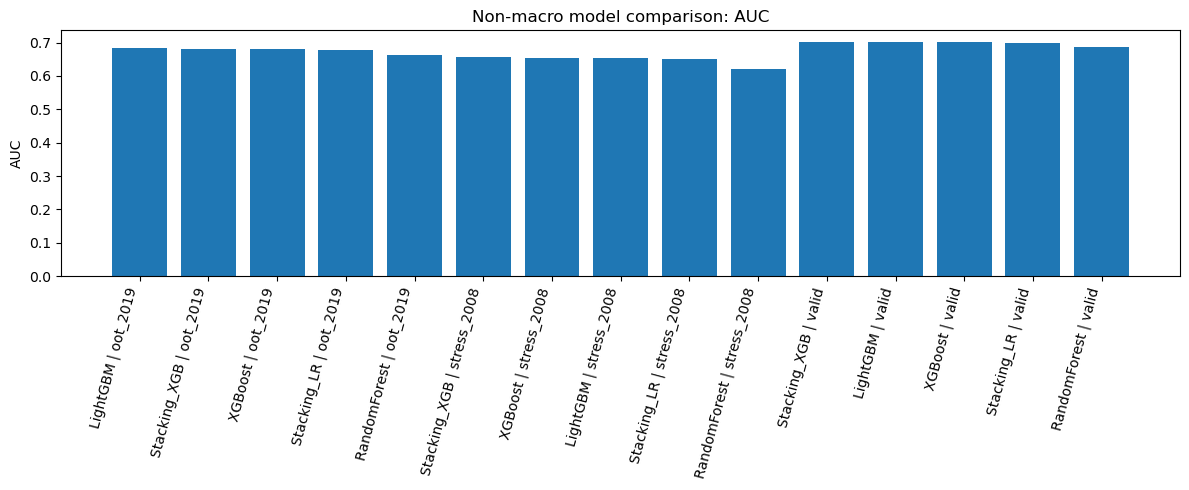

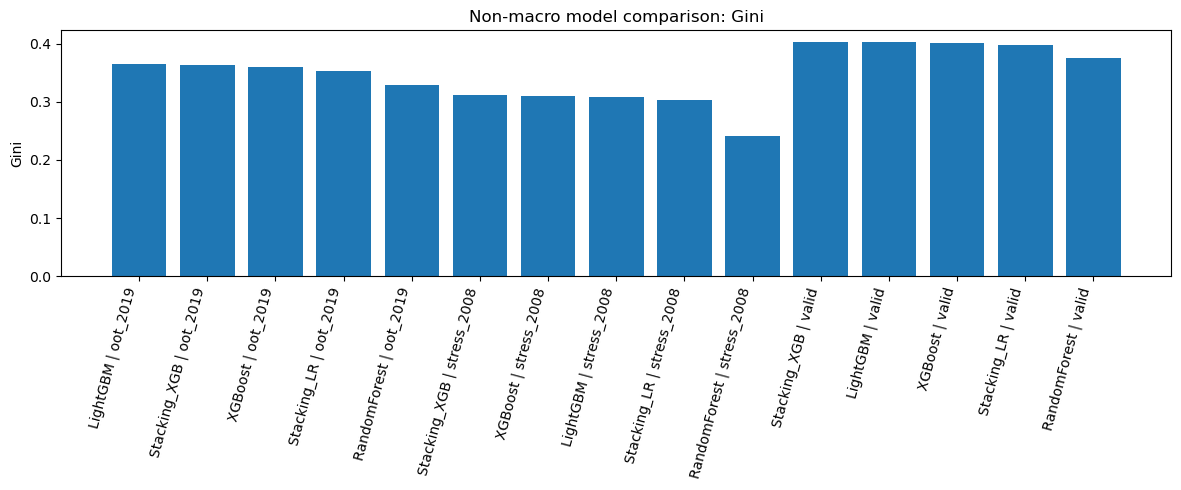

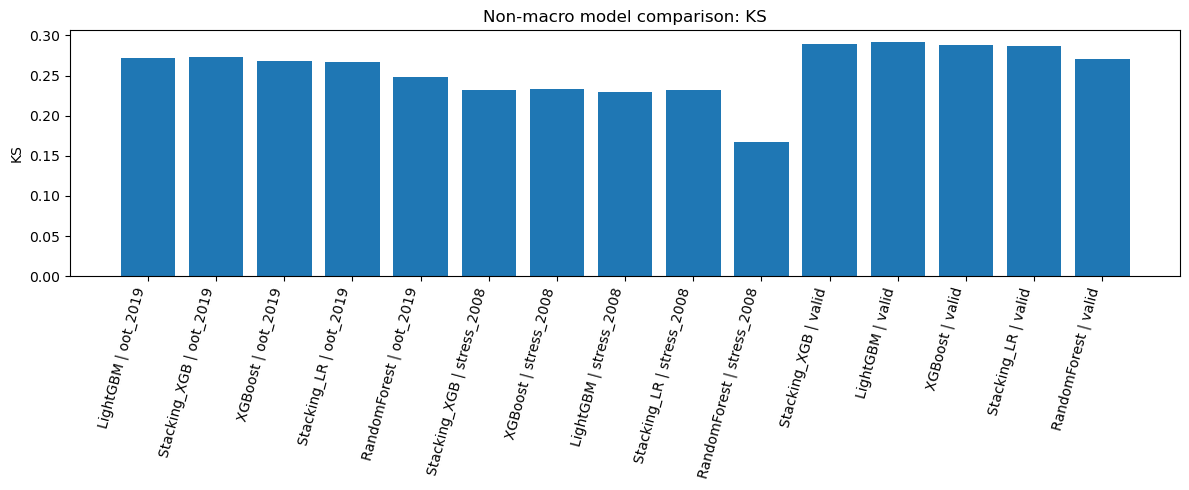

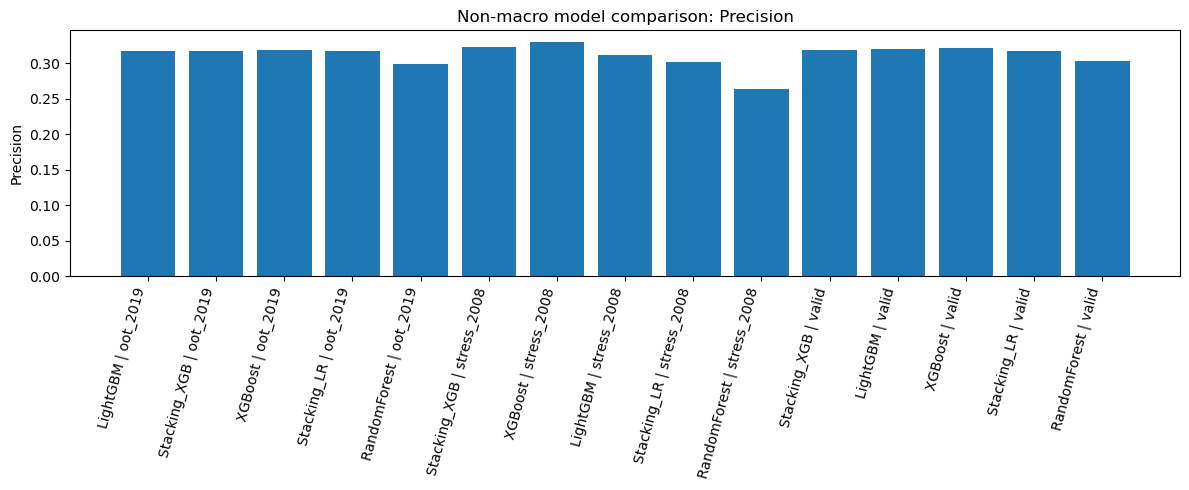

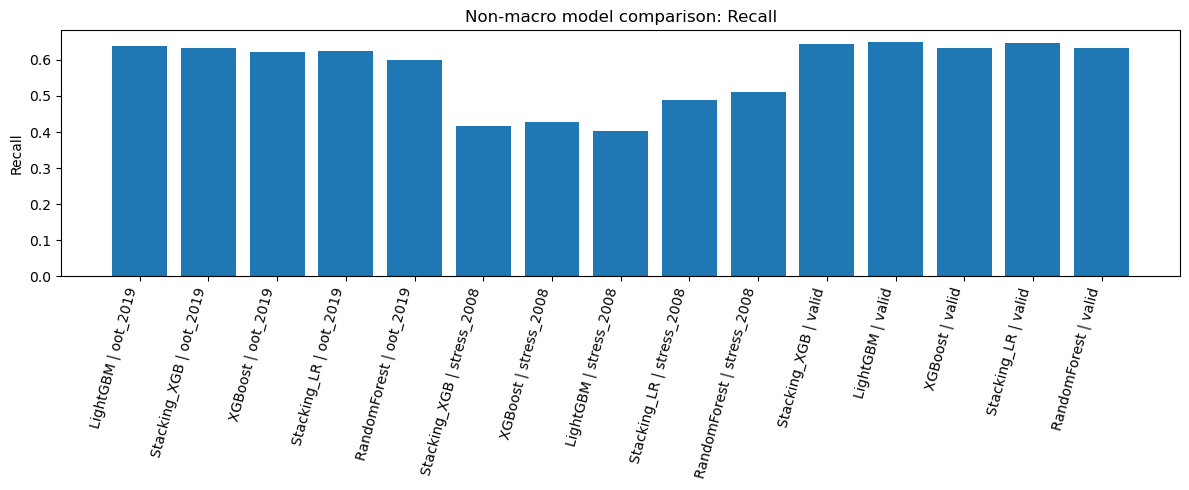

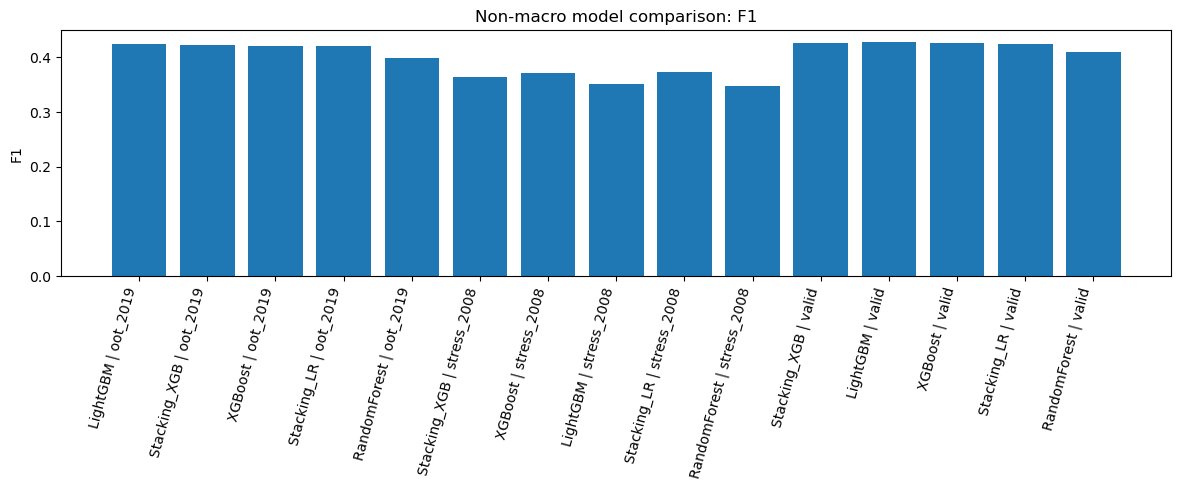

In [390]:
nonmacro_pred_all = pd.concat(
    [
        *prediction_tables.values(),
        stack_valid_pred_df,
        stack_oot_pred_df,
        stack_stress_pred_df,
        stack_lr_valid_pred_df,
        stack_lr_oot_pred_df,
        stack_lr_stress_pred_df
    ],
    axis=0,
    ignore_index=True
)

print("Combined non-macro prediction rows:", nonmacro_pred_all.shape)

nonmacro_psi_frames = []
for m in nonmacro_pred_all["model"].dropna().unique():
    tmp = nonmacro_pred_all[nonmacro_pred_all["model"] == m].copy()
    psi_df = year_to_year_psi(tmp, score_col="prob_default")
    psi_df["Model"] = m
    nonmacro_psi_frames.append(psi_df)

nonmacro_psi_df = (
    pd.concat(nonmacro_psi_frames, axis=0, ignore_index=True)
    if nonmacro_psi_frames else pd.DataFrame()
)

print("Non-macro PSI:")
display(nonmacro_psi_df)

for metric in ["AUC", "Gini", "KS", "Precision", "Recall", "F1"]:
    plt.figure(figsize=(12, 5))
    tmp = nonmacro_final_compare_df.copy()
    labels = tmp["Model"] + " | " + tmp["Split"]
    plt.bar(labels, tmp[metric])
    plt.xticks(rotation=75, ha="right")
    plt.ylabel(metric)
    plt.title(f"Non-macro model comparison: {metric}")
    plt.tight_layout()
    plt.show()

In [391]:
#for with fred

In [392]:
# ============================================================
# CELL 3A — add macro variables from FRED to df_model
# Inflation_L6 + FedFunds_L3 + HomePrices_L12 + UNRATE_L6
# ============================================================

from pandas_datareader import data as web
import pandas as pd

# Ensure datetime
df_model["issue_d_parsed"] = pd.to_datetime(df_model["issue_d_parsed"], errors="coerce")

# Monthly merge key
df_model["issue_month"] = df_model["issue_d_parsed"].dt.to_period("M").dt.to_timestamp()

# Pull enough history so lags are available
fred_codes = {
    "Inflation": "CPIAUCSL",
    "FedFunds": "FEDFUNDS",
    "HomePrices": "CSUSHPISA",
    "UNRATE": "UNRATE"
}

max_lag = 12
start_date = (df_model["issue_month"].min() - pd.DateOffset(months=max_lag + 3)).strftime("%Y-%m-%d")
end_date   = (df_model["issue_month"].max() + pd.DateOffset(months=1)).strftime("%Y-%m-%d")

macro = pd.DataFrame()

for name, code in fred_codes.items():
    s = web.DataReader(code, "fred", start_date, end_date)
    s.index = pd.to_datetime(s.index).to_period("M").to_timestamp()
    macro[name] = s[code]

macro = macro.sort_index().ffill()

# Create exactly the lagged variables you want
macro["Inflation_L6"] = macro["Inflation"].shift(6)
macro["FedFunds_L3"] = macro["FedFunds"].shift(3)
macro["HomePrices_L12"] = macro["HomePrices"].shift(12)
macro["UNRATE_L6"] = macro["UNRATE"].shift(6)

macro_to_merge = (
    macro[["Inflation_L6", "FedFunds_L3", "HomePrices_L12", "UNRATE_L6"]]
    .rename_axis("issue_month")
    .reset_index()
)

# Drop old macro columns first if this cell was run before
old_macro_cols = [
    "Inflation_L6", "FedFunds_L3", "HomePrices_L12", "UNRATE_L6",
    "Inflation_L6_x", "FedFunds_L3_x", "HomePrices_L12_x", "UNRATE_L6_x",
    "Inflation_L6_y", "FedFunds_L3_y", "HomePrices_L12_y", "UNRATE_L6_y"
]
df_model = df_model.drop(columns=[c for c in old_macro_cols if c in df_model.columns], errors="ignore")

# Merge into df_model
df_model = df_model.merge(macro_to_merge, on="issue_month", how="left")

macro_cols = ["Inflation_L6", "FedFunds_L3", "HomePrices_L12", "UNRATE_L6"]

print("Added macro columns:")
print(macro_cols)

print("\nMacro columns found in df_model:")
print(df_model.columns[df_model.columns.isin(macro_cols)].tolist())

print("\nPreview:")
print(df_model[["issue_d_parsed", "issue_month"] + macro_cols].head())

Added macro columns:
['Inflation_L6', 'FedFunds_L3', 'HomePrices_L12', 'UNRATE_L6']

Macro columns found in df_model:
['Inflation_L6', 'FedFunds_L3', 'HomePrices_L12', 'UNRATE_L6']

Preview:
  issue_d_parsed issue_month  Inflation_L6  FedFunds_L3  HomePrices_L12  \
0     2011-12-01  2011-12-01       224.806         0.08         142.049   
1     2011-12-01  2011-12-01       224.806         0.08         142.049   
2     2011-12-01  2011-12-01       224.806         0.08         142.049   
3     2011-12-01  2011-12-01       224.806         0.08         142.049   
4     2011-12-01  2011-12-01       224.806         0.08         142.049   

   UNRATE_L6  
0        9.1  
1        9.1  
2        9.1  
3        9.1  
4        9.1  


In [393]:
# ============================================================
# CELL 3B — rebuild splits after macro merge
# ============================================================

main_oot_years = [2019]
stress_years = [2008]
train_valid_years = [2007, 2009, 2010, 2011, 2012, 2013, 2017, 2018]

main_oot_df = df_model[df_model["issue_year"].isin(main_oot_years)].copy()
stress_df = df_model[df_model["issue_year"].isin(stress_years)].copy()
train_valid_df = df_model[df_model["issue_year"].isin(train_valid_years)].copy()

train_df, valid_df = train_test_split(
    train_valid_df,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=train_valid_df["default"]
)

print("Macro split summary:")
for name, data in [
    ("Train", train_df),
    ("Valid", valid_df),
    ("OOT_2019", main_oot_df),
    ("Stress_2008", stress_df),
]:
    print(
        f"{name:12s} | n = {len(data):>8,d} | "
        f"default rate = {data['default'].mean():.4f} | "
        f"years = {sorted(data['issue_year'].unique().tolist())}"
    )

print("\nCheck macro columns inside train_df:")
print(train_df[["Inflation_L6", "FedFunds_L3", "HomePrices_L12", "UNRATE_L6"]].head())

Macro split summary:
Train        | n =  456,325 | default rate = 0.2054 | years = [2007.0, 2009.0, 2010.0, 2011.0, 2012.0, 2013.0, 2017.0, 2018.0]
Valid        | n =  114,082 | default rate = 0.2054 | years = [2007.0, 2009.0, 2010.0, 2011.0, 2012.0, 2013.0, 2017.0, 2018.0]
OOT_2019     | n =   18,529 | default rate = 0.2137 | years = [2019.0]
Stress_2008  | n =    2,393 | default rate = 0.2073 | years = [2008.0]

Check macro columns inside train_df:
        Inflation_L6  FedFunds_L3  HomePrices_L12  UNRATE_L6
453780       247.284         1.42         189.587        4.2
136479       231.249         0.15         140.144        7.7
40934        212.709         0.16         158.325        9.0
569014       250.227         1.91         194.761        4.0
136891       231.249         0.15         140.144        7.7


In [395]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

cat_cols = ['term', 'home_ownership', 'purpose', 'emp_length']
num_cols = [
    'fico_range_low', 'loan_amnt', 'dti', 'revol_util', 'annual_inc',
    'open_acc', 'delinq_2yrs', 'pub_rec',
    'inq_last_6mths', 'mort_acc', 'revol_bal',
    'Inflation_L6', 'FedFunds_L3', 'HomePrices_L12', 'UNRATE_L6'
]

cat_cols = [c for c in cat_cols if c in train_df.columns]
num_cols = [c for c in num_cols if c in train_df.columns]
feature_cols = cat_cols + num_cols

# ============================================================
# XGB / LGBM
# - keep missing values as NaN
# ============================================================
xgb_lgbm_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="infrequent_if_exist",
                min_frequency=50,
                sparse_output=True
            ),
            cat_cols
        )
    ],
    remainder="drop"
)

X_train_xgb_lgbm = xgb_lgbm_preprocessor.fit_transform(train_df[feature_cols])
X_valid_xgb_lgbm = xgb_lgbm_preprocessor.transform(valid_df[feature_cols])
X_oot_xgb_lgbm = xgb_lgbm_preprocessor.transform(main_oot_df[feature_cols])
X_stress_xgb_lgbm = xgb_lgbm_preprocessor.transform(stress_df[feature_cols])

# ============================================================
# RF
# - drop rows with NA
# - exclude mort_acc because it is fully missing in stress
# ============================================================
rf_feature_cols = [c for c in feature_cols if c != "mort_acc"]

rf_train_df = train_df.dropna(subset=rf_feature_cols).copy()
rf_valid_df = valid_df.dropna(subset=rf_feature_cols).copy()
rf_oot_df = main_oot_df.dropna(subset=rf_feature_cols).copy()
rf_stress_df = stress_df.dropna(subset=rf_feature_cols).copy()

y_train = train_df["default"]
y_valid = valid_df["default"]
y_oot = main_oot_df["default"]
y_stress = stress_df["default"]

y_train_rf = rf_train_df["default"]
y_valid_rf = rf_valid_df["default"]
y_oot_rf = rf_oot_df["default"]
y_stress_rf = rf_stress_df["default"]

rf_cat_cols = [c for c in cat_cols if c in rf_feature_cols]
rf_num_cols = [c for c in num_cols if c in rf_feature_cols]

rf_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", rf_num_cols),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="infrequent_if_exist",
                min_frequency=50,
                sparse_output=True
            ),
            rf_cat_cols
        )
    ],
    remainder="drop"
)

X_train_rf = rf_preprocessor.fit_transform(rf_train_df[rf_feature_cols])
X_valid_rf = rf_preprocessor.transform(rf_valid_df[rf_feature_cols])
X_oot_rf = rf_preprocessor.transform(rf_oot_df[rf_feature_cols])
X_stress_rf = rf_preprocessor.transform(rf_stress_df[rf_feature_cols])

print("Macro XGB/LGBM train shape:", X_train_xgb_lgbm.shape)
print("Macro RF train shape:", X_train_rf.shape)
print("Macro RF rows left:")
print("train:", len(rf_train_df))
print("valid:", len(rf_valid_df))
print("oot:", len(rf_oot_df))
print("stress:", len(rf_stress_df))
print("Macro RF excluded column: mort_acc")

Macro XGB/LGBM train shape: (456325, 49)
Macro RF train shape: (426474, 47)
Macro RF rows left:
train: 426474
valid: 106631
oot: 16602
stress: 2381
Macro RF excluded column: mort_acc


In [396]:
xgb_study, xgb_model, xgb_threshold = run_optuna_xgb()


Tuning XGBoost


Best trial: 84. Best value: 0.424096: 100%|██████████| 100/100 [13:49<00:00,  8.30s/it]


Best validation Gini: 0.424096
Best params: {'reg_alpha': 3.7120893472987526, 'reg_lambda': 2.633102499186743, 'max_depth': 7, 'min_child_weight': 5, 'subsample': 0.8112623240914814, 'colsample_bytree': 0.8149931924509155, 'learning_rate': 0.08122456989445438, 'n_estimators': 191}
Validation KS: 0.305005
Chosen threshold from validation KS: 0.211212


In [397]:
lgbm_study, lgbm_model, lgbm_threshold = run_optuna_lgbm()



Tuning LightGBM


Best trial: 45. Best value: 0.425221: 100%|██████████| 100/100 [12:19<00:00,  7.40s/it]


Best validation Gini: 0.425221
Best params: {'reg_alpha': 3.7077698588618064, 'reg_lambda': 2.624529422654531, 'num_leaves': 82, 'min_child_samples': 23, 'feature_fraction': 0.8349384372105374, 'n_estimators': 289, 'learning_rate': 0.11797003344189826, 'max_depth': 5}
Validation KS: 0.306998
Chosen threshold from validation KS: 0.196358


In [398]:
rf_study, rf_model, rf_threshold = run_optuna_rf()


Tuning Random Forest


Best trial: 13. Best value: 0.40169: 100%|██████████| 25/25 [24:04<00:00, 57.76s/it] 


Best validation Gini: 0.40169
Best params: {'min_samples_split': 28, 'min_samples_leaf': 14, 'n_estimators': 300, 'max_features': 'log2', 'max_depth': None, 'max_leaf_nodes': None}
Validation KS: 0.28741
Chosen threshold from validation KS: 0.209376


In [434]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MaxAbsScaler

# ============================================================
# Logistic Regression baseline (macro)
# Reuses RF complete-case matrices (no NaN, mort_acc excluded)
# ============================================================

lr_scaler   = MaxAbsScaler()
X_train_lr  = lr_scaler.fit_transform(X_train_rf)
X_valid_lr  = lr_scaler.transform(X_valid_rf)
X_oot_lr    = lr_scaler.transform(X_oot_rf)
X_stress_lr = lr_scaler.transform(X_stress_rf)

lr_model = LogisticRegression(
    C=0.1,
    max_iter=1000,
    solver="saga",
    random_state=RANDOM_STATE,
    n_jobs=-1
)
lr_model.fit(X_train_lr, y_train_rf)

lr_valid_prob       = lr_model.predict_proba(X_valid_lr)[:, 1]
lr_ks, lr_threshold = ks_statistic(y_valid_rf, lr_valid_prob)

print(f"LR  Validation KS  : {lr_ks:.4f}")
print(f"LR  Threshold      : {lr_threshold:.4f}")
print(f"LR  Validation Gini: {gini_score(y_valid_rf, lr_valid_prob):.4f}")

LR  Validation KS  : 0.2678
LR  Threshold      : 0.1962
LR  Validation Gini: 0.3698


In [435]:
split_map_lr = {
    "valid":       (X_valid_lr,  y_valid_rf,  rf_valid_df),
    "oot_2019":    (X_oot_lr,    y_oot_rf,    rf_oot_df),
    "stress_2008": (X_stress_lr, y_stress_rf, rf_stress_df)
}

models = {
    "LogisticRegression": (lr_model, lr_threshold),
    "XGBoost":            (xgb_model, xgb_threshold),
    "LightGBM":           (lgbm_model, lgbm_threshold),
    "RandomForest":       (rf_model, rf_threshold)
}

split_map_xgb_lgbm = {
    "valid":       (X_valid_xgb_lgbm,  y_valid,   valid_df),
    "oot_2019":    (X_oot_xgb_lgbm,    y_oot,     main_oot_df),
    "stress_2008": (X_stress_xgb_lgbm, y_stress,  stress_df)
}

split_map_rf = {
    "valid":       (X_valid_rf,  y_valid_rf,  rf_valid_df),
    "oot_2019":    (X_oot_rf,    y_oot_rf,    rf_oot_df),
    "stress_2008": (X_stress_rf, y_stress_rf, rf_stress_df)
}

metrics_rows = []
prediction_tables = {}

for model_name, (model, threshold) in models.items():
    if model_name == "RandomForest":
        split_map = split_map_rf
    elif model_name == "LogisticRegression":
        split_map = split_map_lr
    else:
        split_map = split_map_xgb_lgbm

    for split_name, (X_split, y_split, base_df) in split_map.items():
        prob = model.predict_proba(X_split)[:, 1]
        metrics = evaluate_split(y_split, prob, threshold)

        metrics_rows.append({
            "Model":     model_name,
            "Split":     split_name,
            "Threshold": threshold,
            **metrics
        })

        pred_df = build_prediction_table(
            base_df=base_df,
            y_true=y_split,
            y_prob=prob,
            threshold=threshold,
            model_name=model_name,
            split_name=split_name
        )
        prediction_tables[f"{model_name}_{split_name}"] = pred_df

macro_results_df = pd.DataFrame(metrics_rows).sort_values(
    ["Split", "Gini"], ascending=[True, False]
)
display(macro_results_df)

,Model,Split,Threshold,AUC,Gini,KS,Precision,Recall,F1
7,LightGBM,oot_2019,0.196358,0.688348,0.376697,0.280965,0.305960,0.727273,0.430719
4,XGBoost,oot_2019,0.211212,0.688253,0.376505,0.281161,0.312193,0.691162,0.430109
10,RandomForest,oot_2019,0.209376,0.673476,0.346952,0.256830,0.284714,0.727566,0.409271
1,LogisticRegression,oot_2019,0.196186,0.655478,0.310957,0.226265,0.263923,0.767155,0.392734
5,XGBoost,stress_2008,0.211212,0.668534,0.337069,0.247276,0.297101,0.578629,0.392613
8,LightGBM,stress_2008,0.196358,0.668129,0.336259,0.256580,0.286758,0.633065,0.394720
11,RandomForest,stress_2008,0.209376,0.638203,0.276406,0.192091,0.268799,0.632114,0.377198
2,LogisticRegression,stress_2008,0.196186,0.636101,0.272203,0.198760,0.270973,0.656504,0.383610
6,LightGBM,valid,0.196358,0.712610,0.425221,0.306998,0.318955,0.685118,0.435271
3,XGBoost,valid,0.211212,0.712048,0.424096,0.305005,0.329834,0.642354,0.435863


In [400]:
for name, pred_df in prediction_tables.items():
    save_name = f"macro_{name}_predictions.csv"
    pred_df.to_csv(save_name, index=False)

print("Saved prediction files:")
for name in prediction_tables.keys():
    print(f"- macro_{name}_predictions.csv")

Saved prediction files:
- macro_XGBoost_valid_predictions.csv
- macro_XGBoost_oot_2019_predictions.csv
- macro_XGBoost_stress_2008_predictions.csv
- macro_LightGBM_valid_predictions.csv
- macro_LightGBM_oot_2019_predictions.csv
- macro_LightGBM_stress_2008_predictions.csv
- macro_RandomForest_valid_predictions.csv
- macro_RandomForest_oot_2019_predictions.csv
- macro_RandomForest_stress_2008_predictions.csv


In [401]:
#xgb stacking
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
import optuna
import numpy as np
import pandas as pd

# --- helpers ---
def get_xgb_best_params():
    params = xgb_study.best_params.copy()
    params.update(xgb_fixed)
    return params

def get_lgbm_best_params():
    params = lgbm_study.best_params.copy()
    params.update(lgbm_fixed)
    return params

def get_rf_best_params():
    params = rf_study.best_params.copy()

    max_depth_type = params.pop("max_depth_type", None)
    max_leaf_nodes_type = params.pop("max_leaf_nodes_type", None)

    if max_depth_type == "none":
        params["max_depth"] = None
    if max_leaf_nodes_type == "none":
        params["max_leaf_nodes"] = None

    params.update(rf_fixed)
    return params

xgb_best_params = get_xgb_best_params()
lgbm_best_params = get_lgbm_best_params()
rf_best_params = get_rf_best_params()

print("Base params ready.")
print("XGB:", xgb_best_params)
print("LGBM:", lgbm_best_params)
print("RF:", rf_best_params)

Base params ready.
XGB: {'reg_alpha': 3.7120893472987526, 'reg_lambda': 2.633102499186743, 'max_depth': 7, 'min_child_weight': 5, 'subsample': 0.8112623240914814, 'colsample_bytree': 0.8149931924509155, 'learning_rate': 0.08122456989445438, 'n_estimators': 191, 'objective': 'binary:logistic', 'eval_metric': 'auc', 'tree_method': 'hist', 'random_state': 42, 'n_jobs': -1, 'verbosity': 0}
LGBM: {'reg_alpha': 3.7077698588618064, 'reg_lambda': 2.624529422654531, 'num_leaves': 82, 'min_child_samples': 23, 'feature_fraction': 0.8349384372105374, 'n_estimators': 289, 'learning_rate': 0.11797003344189826, 'max_depth': 5, 'objective': 'binary', 'verbosity': -1, 'random_state': 42, 'n_jobs': -1}
RF: {'min_samples_split': 28, 'min_samples_leaf': 14, 'n_estimators': 300, 'max_features': 'log2', 'max_depth': None, 'max_leaf_nodes': None, 'random_state': 42, 'n_jobs': -1}


In [402]:
# OOF predictions on TRAIN only (XGB + LGBM only)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

n_train = X_train_xgb_lgbm.shape[0]

oof_xgb = np.zeros(n_train)
oof_lgbm = np.zeros(n_train)

for fold, (tr_idx, va_idx) in enumerate(skf.split(X_train_xgb_lgbm, y_train), 1):
    X_tr, X_va = X_train_xgb_lgbm[tr_idx], X_train_xgb_lgbm[va_idx]
    y_tr = y_train.iloc[tr_idx]

    xgb_fold = XGBClassifier(**xgb_best_params)
    lgbm_fold = LGBMClassifier(**lgbm_best_params)

    xgb_fold.fit(X_tr, y_tr)
    lgbm_fold.fit(X_tr, y_tr)

    oof_xgb[va_idx] = xgb_fold.predict_proba(X_va)[:, 1]
    oof_lgbm[va_idx] = lgbm_fold.predict_proba(X_va)[:, 1]

    print(f"Finished fold {fold}/5")

Finished fold 1/5
Finished fold 2/5
Finished fold 3/5
Finished fold 4/5
Finished fold 5/5


In [403]:
valid_prob_xgb = xgb_model.predict_proba(X_valid_xgb_lgbm)[:, 1]
valid_prob_lgbm = lgbm_model.predict_proba(X_valid_xgb_lgbm)[:, 1]

oot_prob_xgb = xgb_model.predict_proba(X_oot_xgb_lgbm)[:, 1]
oot_prob_lgbm = lgbm_model.predict_proba(X_oot_xgb_lgbm)[:, 1]

stress_prob_xgb = xgb_model.predict_proba(X_stress_xgb_lgbm)[:, 1]
stress_prob_lgbm = lgbm_model.predict_proba(X_stress_xgb_lgbm)[:, 1]

In [404]:
meta_train = pd.DataFrame({
    "prob_xgb": oof_xgb,
    "prob_lgbm": oof_lgbm
}, index=y_train.index)

meta_valid = pd.DataFrame({
    "prob_xgb": valid_prob_xgb,
    "prob_lgbm": valid_prob_lgbm
}, index=y_valid.index)

meta_oot = pd.DataFrame({
    "prob_xgb": oot_prob_xgb,
    "prob_lgbm": oot_prob_lgbm
}, index=y_oot.index)

meta_stress = pd.DataFrame({
    "prob_xgb": stress_prob_xgb,
    "prob_lgbm": stress_prob_lgbm
}, index=y_stress.index)

print(meta_train.shape, meta_valid.shape, meta_oot.shape, meta_stress.shape)

(456325, 2) (114082, 2) (18529, 2) (2393, 2)


In [405]:
N_TRIALS_META = 100

meta_study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
meta_study.optimize(meta_xgb_objective, n_trials=N_TRIALS_META, show_progress_bar=True)

meta_best_params = meta_study.best_params.copy()
meta_best_params.update({
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "tree_method": "hist",
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "verbosity": 0
})

print("Best meta validation Gini:", round(meta_study.best_value, 6))
print("Best meta params:", meta_best_params)

Best trial: 99. Best value: 0.426038: 100%|██████████| 100/100 [02:11<00:00,  1.31s/it]

Best meta validation Gini: 0.426038
Best meta params: {'n_estimators': 108, 'max_depth': 4, 'learning_rate': 0.011956923863064989, 'subsample': 0.7313567379535864, 'colsample_bytree': 0.8240570311830995, 'min_child_weight': 8, 'reg_alpha': 1.0606499077852465, 'reg_lambda': 3.275121922117985, 'objective': 'binary:logistic', 'eval_metric': 'auc', 'tree_method': 'hist', 'random_state': 42, 'n_jobs': -1, 'verbosity': 0}


In [406]:
meta_xgb_model = XGBClassifier(**meta_best_params)
meta_xgb_model.fit(meta_train, y_train)

stack_valid_prob = meta_xgb_model.predict_proba(meta_valid)[:, 1]
stack_oot_prob = meta_xgb_model.predict_proba(meta_oot)[:, 1]
stack_stress_prob = meta_xgb_model.predict_proba(meta_stress)[:, 1]

stack_valid_pred_df = make_pred_df(
    valid_df, y_valid, stack_valid_prob, stack_threshold, "valid", "Stacking_XGB"
)
stack_oot_pred_df = make_pred_df(
    main_oot_df, y_oot, stack_oot_prob, stack_threshold, "oot_2019", "Stacking_XGB"
)
stack_stress_pred_df = make_pred_df(
    stress_df, y_stress, stack_stress_prob, stack_threshold, "stress_2008", "Stacking_XGB"
)

stack_valid_pred_df.to_csv("stacking_xgb_valid_predictions.csv", index=False)
stack_oot_pred_df.to_csv("stacking_xgb_oot_2019_predictions.csv", index=False)
stack_stress_pred_df.to_csv("stacking_xgb_stress_2008_predictions.csv", index=False)

display(stack_valid_pred_df.head())
display(stack_oot_pred_df.head())
display(stack_stress_pred_df.head())

,issue_d,issue_year,actual_default,pred_label,prob_non_default,prob_default,model,split
49219,Dec-13,2013.0,0,0,0.884445,0.115555,Stacking_XGB,valid
357492,Oct-17,2017.0,1,1,0.603418,0.396582,Stacking_XGB,valid
402544,Feb-18,2018.0,0,0,0.811923,0.188077,Stacking_XGB,valid
408423,Feb-18,2018.0,0,1,0.618611,0.381389,Stacking_XGB,valid
191622,Oct-12,2012.0,0,0,0.870981,0.129020,Stacking_XGB,valid


,issue_d,issue_year,actual_default,pred_label,prob_non_default,prob_default,model,split
572800,Mar-19,2019.0,0,0,0.825444,0.174556,Stacking_XGB,oot_2019
572801,Mar-19,2019.0,0,0,0.896088,0.103912,Stacking_XGB,oot_2019
572802,Mar-19,2019.0,1,1,0.610144,0.389856,Stacking_XGB,oot_2019
572803,Mar-19,2019.0,0,1,0.751809,0.248191,Stacking_XGB,oot_2019
572804,Mar-19,2019.0,0,1,0.716724,0.283276,Stacking_XGB,oot_2019


,issue_d,issue_year,actual_default,pred_label,prob_non_default,prob_default,model,split
37968,Dec-08,2008.0,0,0,0.891126,0.108874,Stacking_XGB,stress_2008
37969,Dec-08,2008.0,1,0,0.847575,0.152425,Stacking_XGB,stress_2008
37970,Dec-08,2008.0,0,1,0.707273,0.292727,Stacking_XGB,stress_2008
37972,Dec-08,2008.0,0,0,0.845362,0.154638,Stacking_XGB,stress_2008
37973,Dec-08,2008.0,0,0,0.845064,0.154936,Stacking_XGB,stress_2008


In [407]:
def make_pred_df(base_df, y_true, prob, threshold, split_name, model_name):
    pred = (prob >= threshold).astype(int)
    out = pd.DataFrame({
        "issue_d": base_df["issue_d"].values if "issue_d" in base_df.columns else None,
        "issue_year": base_df["issue_year"].values if "issue_year" in base_df.columns else None,
        "actual_default": y_true.values,
        "pred_label": pred,
        "prob_non_default": 1 - prob,
        "prob_default": prob,
        "model": model_name,
        "split": split_name
    }, index=y_true.index)
    return out

stack_valid_pred_df = make_pred_df(
    valid_df,
    y_valid,
    meta_xgb_model.predict_proba(meta_valid)[:, 1],
    stack_threshold,
    "valid",
    "Stacking_XGB"
)

stack_oot_pred_df = make_pred_df(
    main_oot_df,
    y_oot,
    meta_xgb_model.predict_proba(meta_oot)[:, 1],
    stack_threshold,
    "oot_2019",
    "Stacking_XGB"
)

stack_stress_pred_df = make_pred_df(
    stress_df,
    y_stress,
    meta_xgb_model.predict_proba(meta_stress)[:, 1],
    stack_threshold,
    "stress_2008",
    "Stacking_XGB"
)

stack_valid_pred_df.to_csv("macro_stacking_xgb_valid_predictions.csv", index=False)
stack_oot_pred_df.to_csv("macro_stacking_xgb_oot_2019_predictions.csv", index=False)
stack_stress_pred_df.to_csv("macro_stacking_xgb_stress_2008_predictions.csv", index=False)

print("Saved:")
print("- macro_stacking_xgb_valid_predictions.csv")
print("- macro_stacking_xgb_oot_2019_predictions.csv")
print("- macro_stacking_xgb_stress_2008_predictions.csv")

Saved:
- macro_stacking_xgb_valid_predictions.csv
- macro_stacking_xgb_oot_2019_predictions.csv
- macro_stacking_xgb_stress_2008_predictions.csv


In [408]:
#logistic stacking
from sklearn.linear_model import LogisticRegression

meta_lr_model = LogisticRegression(
    C=1.0,
    penalty="l2",
    solver="lbfgs",
    max_iter=2000,
    random_state=RANDOM_STATE
)

meta_lr_model.fit(meta_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


In [409]:
stack_lr_valid_prob = meta_lr_model.predict_proba(meta_valid)[:, 1]
stack_lr_valid_ks, stack_lr_threshold = ks_statistic(y_valid, stack_lr_valid_prob)

print("Stacking-LR validation Gini:", round(gini_score(y_valid, stack_lr_valid_prob), 6))
print("Stacking-LR validation KS:", round(stack_lr_valid_ks, 6))
print("Chosen threshold:", round(stack_lr_threshold, 6))

Stacking-LR validation Gini: 0.426146
Stacking-LR validation KS: 0.307912
Chosen threshold: 0.184214


In [410]:
stack_lr_results = []

for split_name, X_split, y_split in [
    ("valid", meta_valid, y_valid),
    ("oot_2019", meta_oot, y_oot),
    ("stress_2008", meta_stress, y_stress),
]:
    prob = meta_lr_model.predict_proba(X_split)[:, 1]
    metrics = evaluate_split(y_split, prob, stack_lr_threshold)

    stack_lr_results.append({
        "Model": "Stacking_LR",
        "Split": split_name,
        "Threshold": stack_lr_threshold,
        **metrics
    })

macro_stack_lr_results_df = pd.DataFrame(stack_lr_results)
display(macro_stack_lr_results_df)

,Model,Split,Threshold,AUC,Gini,KS,Precision,Recall,F1
0,Stacking_LR,valid,0.184214,0.713073,0.426146,0.307912,0.326449,0.659767,0.436781
1,Stacking_LR,oot_2019,0.184214,0.689212,0.378425,0.280983,0.310211,0.708081,0.431418
2,Stacking_LR,stress_2008,0.184214,0.670273,0.340546,0.248153,0.299120,0.616935,0.402897


In [411]:
def make_pred_df(base_df, y_true, prob, threshold, split_name, model_name):
    pred = (prob >= threshold).astype(int)
    out = pd.DataFrame({
        "issue_d": base_df["issue_d"].values if "issue_d" in base_df.columns else None,
        "issue_year": base_df["issue_year"].values if "issue_year" in base_df.columns else None,
        "actual_default": y_true.values,
        "pred_label": pred,
        "prob_non_default": 1 - prob,
        "prob_default": prob,
        "model": model_name,
        "split": split_name
    }, index=y_true.index)
    return out

stack_lr_valid_pred_df = make_pred_df(
    valid_df, y_valid,
    meta_lr_model.predict_proba(meta_valid)[:, 1],
    stack_lr_threshold, "valid", "Stacking_LR"
)

stack_lr_oot_pred_df = make_pred_df(
    main_oot_df, y_oot,
    meta_lr_model.predict_proba(meta_oot)[:, 1],
    stack_lr_threshold, "oot_2019", "Stacking_LR"
)

stack_lr_stress_pred_df = make_pred_df(
    stress_df, y_stress,
    meta_lr_model.predict_proba(meta_stress)[:, 1],
    stack_lr_threshold, "stress_2008", "Stacking_LR"
)

stack_lr_valid_pred_df.to_csv("stacking_lr_valid_predictions.csv", index=False)
stack_lr_oot_pred_df.to_csv("stacking_lr_oot_2019_predictions.csv", index=False)
stack_lr_stress_pred_df.to_csv("stacking_lr_stress_2008_predictions.csv", index=False)

print("Saved:")
print("- stacking_lr_valid_predictions.csv")
print("- stacking_lr_oot_2019_predictions.csv")
print("- stacking_lr_stress_2008_predictions.csv")

Saved:
- stacking_lr_valid_predictions.csv
- stacking_lr_oot_2019_predictions.csv
- stacking_lr_stress_2008_predictions.csv


In [412]:
stack_xgb_results = []

for split_name, X_split, y_split in [
    ("valid", meta_valid, y_valid),
    ("oot_2019", meta_oot, y_oot),
    ("stress_2008", meta_stress, y_stress),
]:
    prob = meta_xgb_model.predict_proba(X_split)[:, 1]
    metrics = evaluate_split(y_split, prob, stack_threshold)

    stack_xgb_results.append({
        "Model": "Stacking_XGB",
        "Split": split_name,
        "Threshold": stack_threshold,
        **metrics
    })

stack_xgb_results_df = pd.DataFrame(stack_xgb_results)

macro_final_compare_df = pd.concat(
    [macro_results_df, stack_xgb_results_df, stack_lr_results_df],
    axis=0,
    ignore_index=True
)

macro_final_compare_df = macro_final_compare_df.sort_values(
    ["Split", "Gini"], ascending=[True, False]
).reset_index(drop=True)

display(macro_final_compare_df)

,Model,Split,Threshold,AUC,Gini,KS,Precision,Recall,F1
0,Stacking_XGB,oot_2019,0.217567,0.689236,0.378473,0.282092,0.316734,0.668182,0.429755
1,LightGBM,oot_2019,0.196358,0.688348,0.376697,0.280965,0.305960,0.727273,0.430719
2,XGBoost,oot_2019,0.211212,0.688253,0.376505,0.281161,0.312193,0.691162,0.430109
3,Stacking_LR,oot_2019,0.187132,0.676149,0.352298,0.266404,0.317726,0.623737,0.420999
4,RandomForest,oot_2019,0.209376,0.673476,0.346952,0.256830,0.284714,0.727566,0.409271
5,Stacking_XGB,stress_2008,0.217567,0.671027,0.342053,0.250633,0.303879,0.568548,0.396067
6,XGBoost,stress_2008,0.211212,0.668534,0.337069,0.247276,0.297101,0.578629,0.392613
7,LightGBM,stress_2008,0.196358,0.668129,0.336259,0.256580,0.286758,0.633065,0.394720
8,Stacking_LR,stress_2008,0.187132,0.651509,0.303019,0.231655,0.301370,0.487903,0.372594
9,RandomForest,stress_2008,0.209376,0.638203,0.276406,0.192091,0.268799,0.632114,0.377198


Combined macro prediction rows: (665630, 8)
Macro PSI:


,Year_1,Year_2,PSI,Model
0,2007,2008,0.222604,XGBoost
1,2008,2009,0.623130,XGBoost
2,2009,2010,0.079615,XGBoost
3,2010,2011,0.008026,XGBoost
4,2011,2012,0.067825,XGBoost
5,2012,2013,0.005106,XGBoost
6,2013,2017,0.404239,XGBoost
7,2017,2018,0.003686,XGBoost
8,2018,2019,0.015960,XGBoost
9,2007,2008,0.249376,LightGBM


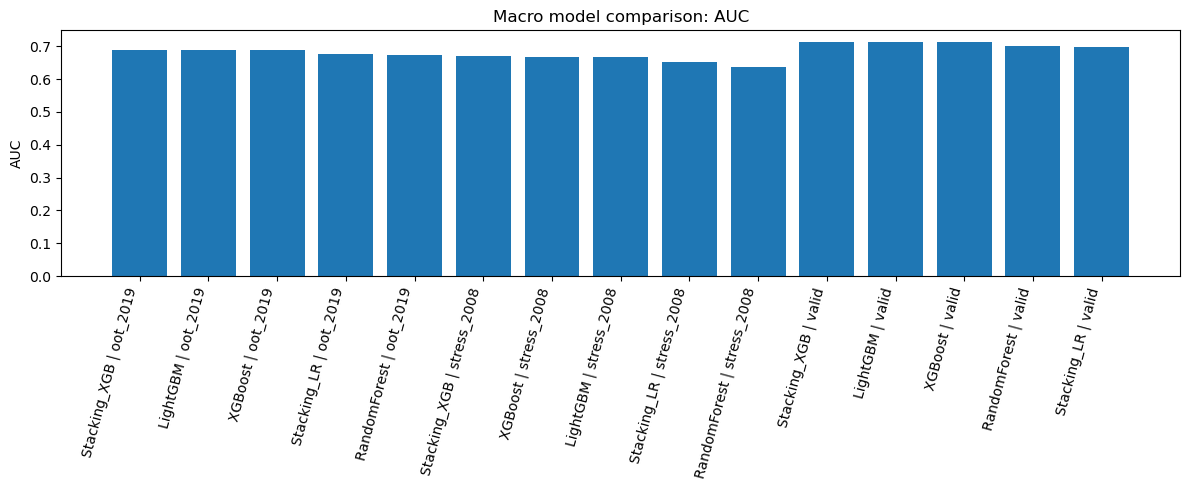

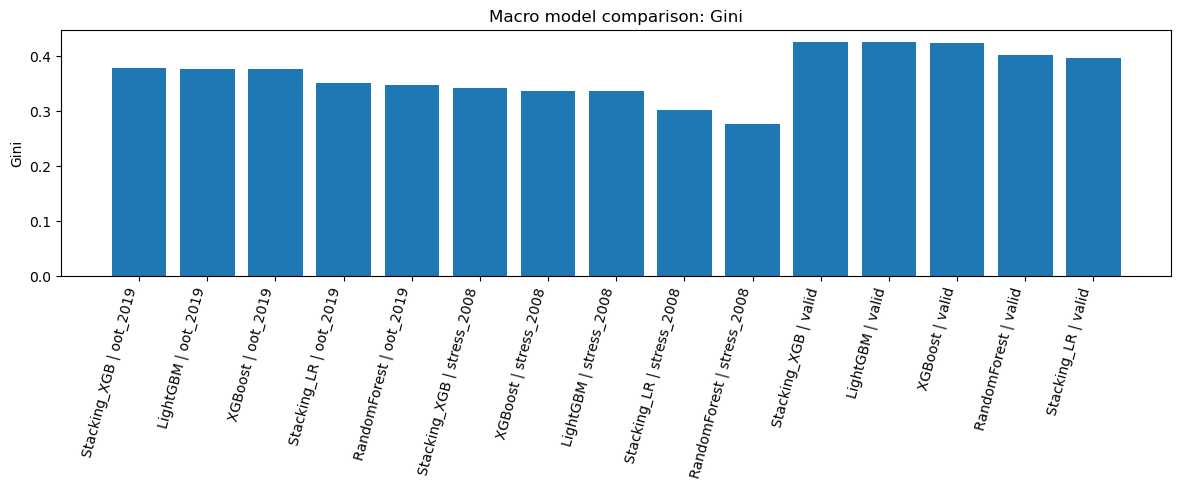

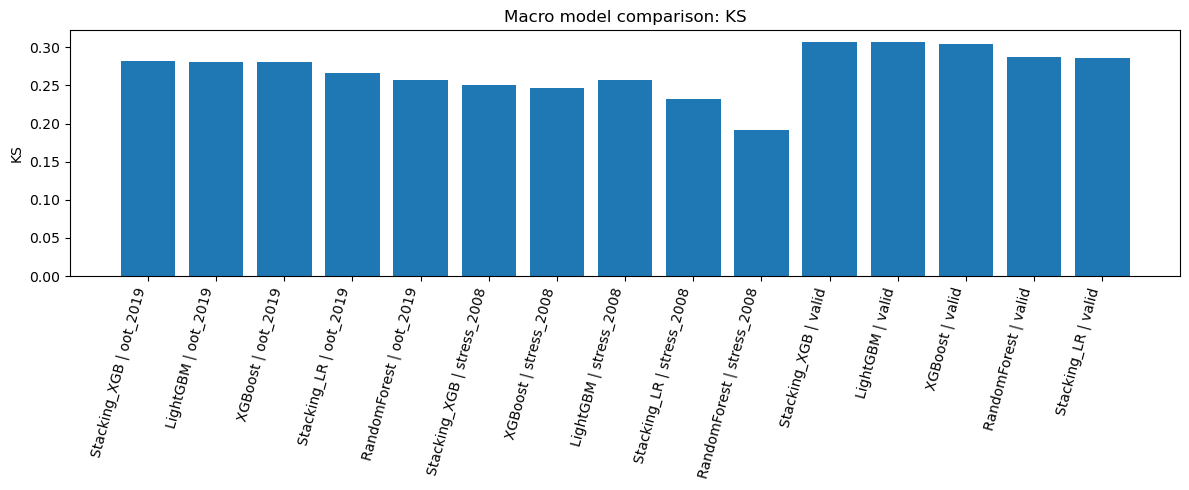

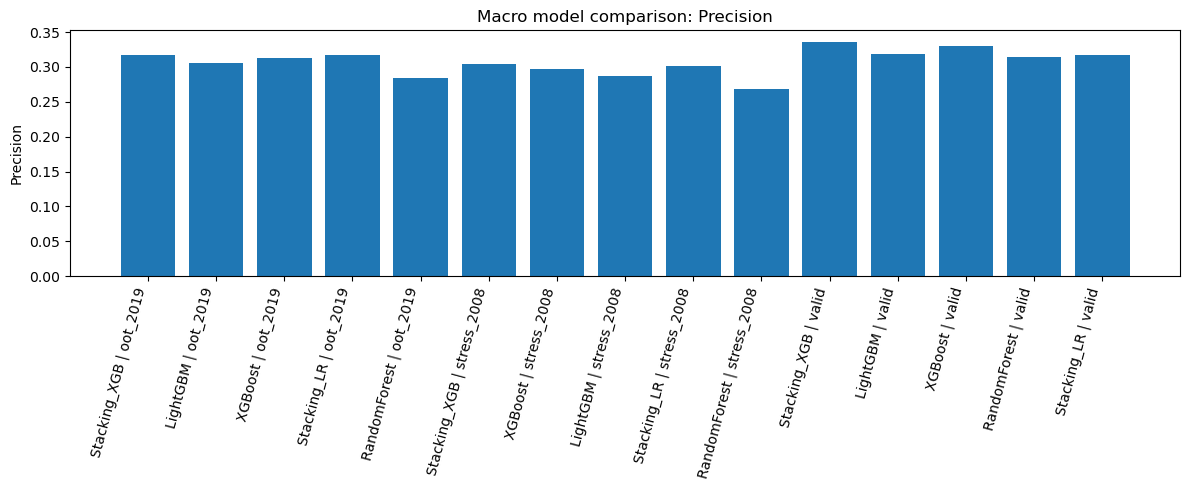

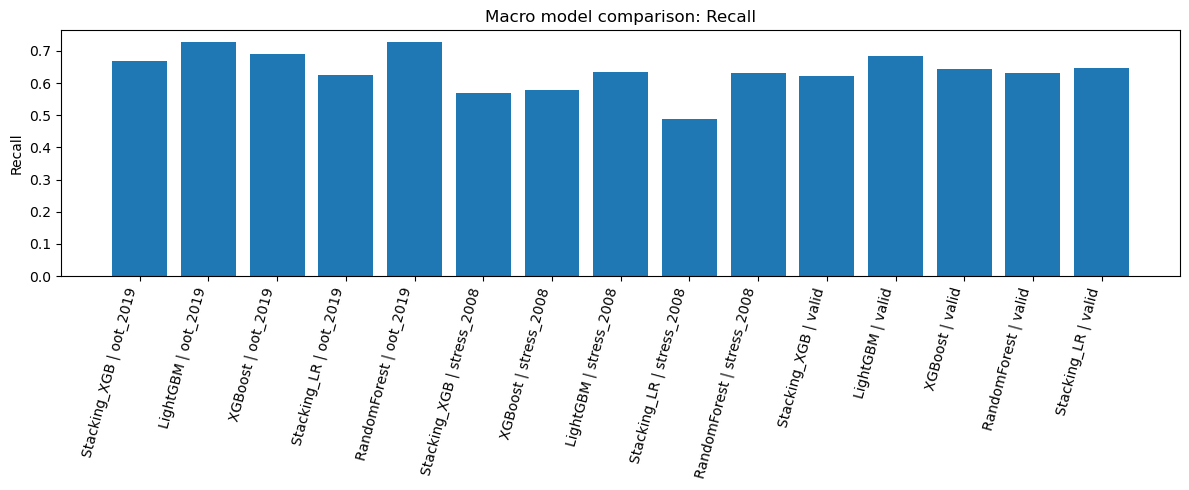

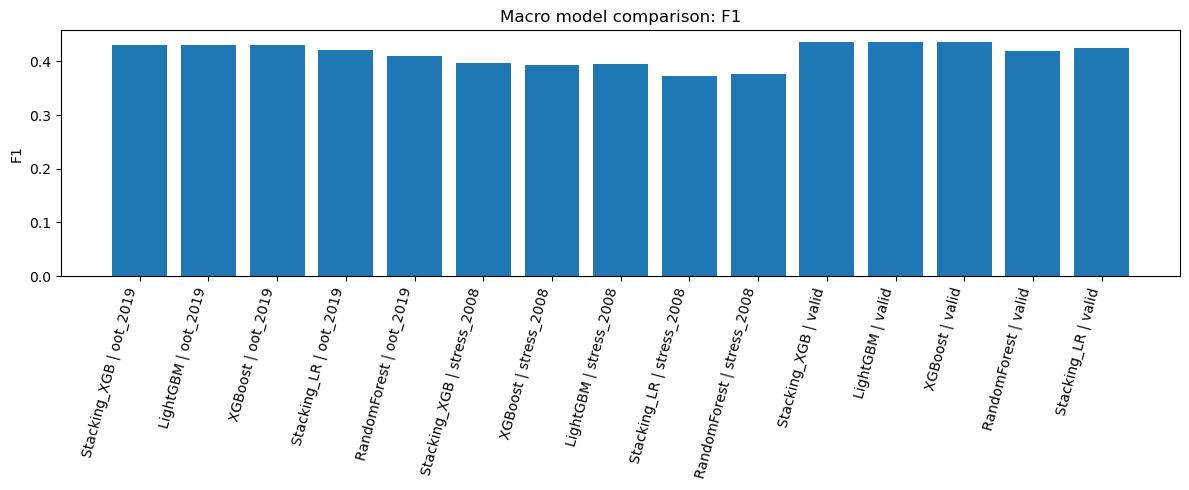

In [413]:
macro_pred_all = pd.concat(
    [
        *prediction_tables.values(),
        stack_valid_pred_df,
        stack_oot_pred_df,
        stack_stress_pred_df,
        stack_lr_valid_pred_df,
        stack_lr_oot_pred_df,
        stack_lr_stress_pred_df
    ],
    axis=0,
    ignore_index=True
)

print("Combined macro prediction rows:", macro_pred_all.shape)

macro_psi_frames = []
for m in macro_pred_all["model"].dropna().unique():
    tmp = macro_pred_all[macro_pred_all["model"] == m].copy()
    psi_df = year_to_year_psi(tmp, score_col="prob_default")
    psi_df["Model"] = m
    macro_psi_frames.append(psi_df)

macro_psi_df = (
    pd.concat(macro_psi_frames, axis=0, ignore_index=True)
    if macro_psi_frames else pd.DataFrame()
)

print("Macro PSI:")
display(macro_psi_df)

for metric in ["AUC", "Gini", "KS", "Precision", "Recall", "F1"]:
    plt.figure(figsize=(12, 5))
    tmp = macro_final_compare_df.copy()
    labels = tmp["Model"] + " | " + tmp["Split"]
    plt.bar(labels, tmp[metric])
    plt.xticks(rotation=75, ha="right")
    plt.ylabel(metric)
    plt.title(f"Macro model comparison: {metric}")
    plt.tight_layout()
    plt.show()

In [414]:
# ============================================================
# BLOCK 33 — refit final deploy LightGBM
# use all non-stress data for deployment
# ============================================================

from sklearn.base import clone
from lightgbm import LGBMClassifier

# Keep stress_2008 as a historical stress reference, not deployment training data
deploy_df = pd.concat([train_valid_df, main_oot_df], axis=0).copy()

print("Deploy dataset shape:", deploy_df.shape)
print("Deploy years:", sorted(deploy_df["issue_year"].unique().tolist()))
print("Deploy default rate:", round(deploy_df["default"].mean(), 6))

# final raw feature schema
cat_cols_final = ['term', 'home_ownership', 'purpose', 'emp_length']

num_cols_final = [
    'fico_range_low', 'loan_amnt', 'dti', 'revol_util', 'annual_inc',
    'open_acc', 'delinq_2yrs', 'pub_rec',
    'inq_last_6mths', 'mort_acc', 'revol_bal',
    'Inflation_L6', 'FedFunds_L3', 'HomePrices_L12', 'UNRATE_L6'
]
feature_cols_final = cat_cols_final + num_cols_final

# safety
cat_cols_final = [c for c in cat_cols_final if c in deploy_df.columns]
num_cols_final = [c for c in num_cols_final if c in deploy_df.columns]
feature_cols_final = cat_cols_final + num_cols_final

deploy_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median"))
            ]),
            num_cols_final
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(
                    handle_unknown="infrequent_if_exist",
                    min_frequency=50,
                    sparse_output=True
                ))
            ]),
            cat_cols_final
        )
    ],
    remainder="drop"
)

X_deploy = deploy_preprocessor.fit_transform(deploy_df[feature_cols_final])
y_deploy = deploy_df["default"].astype(int).copy()

# use the tuned best LightGBM settings from your Optuna study
lgbm_best_params = lgbm_study.best_params.copy()

deploy_lgbm_model = LGBMClassifier(
    **lgbm_best_params,
    **lgbm_fixed
)

deploy_lgbm_model.fit(X_deploy, y_deploy)

print("Deploy LightGBM trained.")
print("X_deploy shape:", X_deploy.shape)
print("n raw features:", len(feature_cols_final))

Deploy dataset shape: (588936, 24)
Deploy years: [2007.0, 2009.0, 2010.0, 2011.0, 2012.0, 2013.0, 2017.0, 2018.0, 2019.0]
Deploy default rate: 0.205645
Deploy LightGBM trained.
X_deploy shape: (588936, 48)
n raw features: 19


In [415]:
# ============================================================
# BLOCK 34 — macro helper for one application date
# ============================================================

from pandas_datareader import data as web
import pandas as pd

def get_macro_features_for_date(application_date):
    """
    application_date: string or datetime like '2018-01-01'
    returns:
    Inflation_L6, FedFunds_L3, HomePrices_L12, UNRATE_L6
    """
    app_month = pd.Timestamp(application_date).to_period("M").to_timestamp()

    start_date = (app_month - pd.DateOffset(months=18)).strftime("%Y-%m-%d")
    end_date = app_month.strftime("%Y-%m-%d")

    fred_codes = {
        "Inflation": "CPIAUCSL",
        "FedFunds": "FEDFUNDS",
        "HomePrices": "CSUSHPISA",
        "UNRATE": "UNRATE"
    }

    macro = pd.DataFrame()

    for name, code in fred_codes.items():
        s = web.DataReader(code, "fred", start_date, end_date)
        s.index = pd.to_datetime(s.index).to_period("M").to_timestamp()
        macro[name] = s[code]

    macro = macro.sort_index().ffill()

    out = {
        "Inflation_L6": float(macro["Inflation"].shift(6).dropna().iloc[-1]),
        "FedFunds_L3": float(macro["FedFunds"].shift(3).dropna().iloc[-1]),
        "HomePrices_L12": float(macro["HomePrices"].shift(12).dropna().iloc[-1]),
        "UNRATE_L6": float(macro["UNRATE"].shift(6).dropna().iloc[-1]),
    }

    return out

# quick sanity check
print(get_macro_features_for_date("2018-01-01"))

{'Inflation_L6': 244.243, 'FedFunds_L3': 1.15, 'HomePrices_L12': 186.774, 'UNRATE_L6': 4.3}


In [416]:
# ============================================================
# BLOCK 35 — single-applicant prediction helper
# ============================================================

import numpy as np
import pandas as pd

def build_single_applicant_row(applicant_dict, application_date):
    macro_dict = get_macro_features_for_date(application_date)

    row = {**applicant_dict, **macro_dict}
    row_df = pd.DataFrame([row])

    for col in feature_cols_final:
        if col not in row_df.columns:
            row_df[col] = np.nan

    row_df = row_df[feature_cols_final]
    return row_df

def predict_single_applicant(applicant_dict, application_date):
    row_df = build_single_applicant_row(applicant_dict, application_date)
    X_row = deploy_preprocessor.transform(row_df)
    pd_hat = deploy_lgbm_model.predict_proba(X_row)[:, 1][0]
    return float(pd_hat), row_df

In [417]:
# ============================================================
# BLOCK 36 — manual sanity test cases
# ============================================================

test_cases = {
    "low_risk_case": {
        "term": "36 months",
        "home_ownership": "MORTGAGE",
        "purpose": "debt_consolidation",
        "emp_length": "10+ years",
        "fico_range_low": 760,
        "loan_amnt": 8000,
        "dti": 10.5,
        "revol_util": 22.0,
        "annual_inc": 120000,
        "open_acc": 12,
        "delinq_2yrs": 0,
        "pub_rec": 0,
        "inq_last_6mths": 0,
        "mort_acc": 2,
        "revol_bal": 8000
    },
    "medium_risk_case": {
        "term": "36 months",
        "home_ownership": "RENT",
        "purpose": "credit_card",
        "emp_length": "3 years",
        "fico_range_low": 680,
        "loan_amnt": 15000,
        "dti": 18.0,
        "revol_util": 45.0,
        "annual_inc": 70000,
        "open_acc": 8,
        "delinq_2yrs": 0,
        "pub_rec": 0,
        "inq_last_6mths": 1,
        "mort_acc": 0,
        "revol_bal": 12000
    },
    "high_risk_case": {
        "term": "60 months",
        "home_ownership": "RENT",
        "purpose": "small_business",
        "emp_length": "< 1 year",
        "fico_range_low": 610,
        "loan_amnt": 25000,
        "dti": 32.0,
        "revol_util": 82.0,
        "annual_inc": 38000,
        "open_acc": 5,
        "delinq_2yrs": 2,
        "pub_rec": 1,
        "inq_last_6mths": 4,
        "mort_acc": 0,
        "revol_bal": 22000
    }
}

test_rows = []

for case_name, profile in test_cases.items():
    pd_hat, row_df = predict_single_applicant(profile, "2018-01-01")
    test_rows.append({
        "case": case_name,
        "predicted_pd": pd_hat
    })

test_results_df = pd.DataFrame(test_rows).sort_values("predicted_pd")
test_results_df

,case,predicted_pd
0,low_risk_case,0.074135
1,medium_risk_case,0.394197
2,high_risk_case,0.828981


In [418]:
# ============================================================
# BLOCK 37 — SHAP explainer for LightGBM
# ============================================================

import shap
import pandas as pd
import numpy as np

feature_names_transformed = deploy_preprocessor.get_feature_names_out()
deploy_explainer = shap.TreeExplainer(deploy_lgbm_model)

def get_single_prediction_explanation(applicant_dict, application_date, top_n=10):
    row_df = build_single_applicant_row(applicant_dict, application_date)
    X_row = deploy_preprocessor.transform(row_df)

    pd_hat = deploy_lgbm_model.predict_proba(X_row)[:, 1][0]

    shap_values = deploy_explainer.shap_values(X_row)

    # handle different SHAP return formats
    if isinstance(shap_values, list):
        sv = shap_values[1][0]
    else:
        sv = shap_values[0]

    contrib_df = pd.DataFrame({
        "feature": feature_names_transformed,
        "shap_value": sv
    })

    contrib_df["abs_shap"] = contrib_df["shap_value"].abs()
    contrib_df = contrib_df.sort_values("abs_shap", ascending=False).reset_index(drop=True)

    return float(pd_hat), row_df, contrib_df.head(top_n)

In [419]:
# ============================================================
# BLOCK 38 — SHAP test on one case
# ============================================================

pd_hat, row_df, contrib_df = get_single_prediction_explanation(
    test_cases["medium_risk_case"],
    "2018-01-01",
    top_n=12
)

print("Predicted PD:", round(pd_hat, 6))
display(row_df)
display(contrib_df)

Predicted PD: 0.394197


,term,home_ownership,purpose,emp_length,fico_range_low,loan_amnt,dti,revol_util,annual_inc,open_acc,delinq_2yrs,pub_rec,inq_last_6mths,mort_acc,revol_bal,Inflation_L6,FedFunds_L3,HomePrices_L12,UNRATE_L6
0,36 months,RENT,credit_card,3 years,680,15000,18.0,45.0,70000,8,0,0,1,0,12000,244.243,1.15,186.774,4.3


,feature,shap_value,abs_shap
0,cat__term_ 36 months,0.479436,0.479436
1,num__fico_range_low,0.241972,0.241972
2,num__mort_acc,0.211006,0.211006
3,cat__purpose_credit_card,-0.130025,0.130025
4,num__inq_last_6mths,0.125460,0.125460
5,num__Inflation_L6,0.095499,0.095499
6,cat__home_ownership_RENT,0.085664,0.085664
7,num__HomePrices_L12,0.071658,0.071658
8,num__dti,-0.067092,0.067092
9,cat__home_ownership_MORTGAGE,0.038596,0.038596


In [420]:
# ============================================================
# BLOCK 39 — convert SHAP into readable reason codes
# ============================================================

pretty_name_map = {
    "fico_range_low": "FICO score",
    "loan_amnt": "Loan amount",
    "dti": "Debt-to-income ratio",
    "revol_util": "Revolving utilization",
    "annual_inc": "Annual income",
    "open_acc": "Open accounts",
    "delinq_2yrs": "Recent delinquencies",
    "pub_rec": "Public records",
    "inq_last_6mths": "Recent credit inquiries",
    "mort_acc": "Mortgage accounts",
    "revol_bal": "Revolving balance",
    "Inflation_L6": "Inflation backdrop",
    "FedFunds_L3": "Fed funds backdrop",
    "HomePrices_L12": "Home price backdrop",
    "UNRATE_L6": "Unemployment backdrop",
    "term": "Loan term",
    "home_ownership": "Home ownership",
    "purpose": "Loan purpose",
    "emp_length": "Employment length"
}

def prettify_feature_name(raw_name):
    if raw_name in pretty_name_map:
        return pretty_name_map[raw_name]
    return raw_name.replace("cat__", "").replace("num__", "")

def summarize_explanation(contrib_df, top_n=8):
    tmp = contrib_df.head(top_n).copy()
    tmp["pretty_feature"] = tmp["feature"].apply(prettify_feature_name)

    risk_up = tmp[tmp["shap_value"] > 0]["pretty_feature"].tolist()
    risk_down = tmp[tmp["shap_value"] < 0]["pretty_feature"].tolist()

    return {
        "risk_increasing_factors": risk_up,
        "risk_reducing_factors": risk_down
    }

summary = summarize_explanation(contrib_df, top_n=8)
summary

{'risk_increasing_factors': ['term_ 36 months',
  'fico_range_low',
  'mort_acc',
  'inq_last_6mths',
  'Inflation_L6',
  'home_ownership_RENT',
  'HomePrices_L12'],
 'risk_reducing_factors': ['purpose_credit_card']}

In [421]:
# ============================================================
# BLOCK 39A — group SHAP to original business features
# ============================================================

def get_raw_feature_name(transformed_name, cat_cols, num_cols):
    if transformed_name.startswith("num__"):
        return transformed_name.replace("num__", "")
    
    if transformed_name.startswith("cat__"):
        cat_part = transformed_name.replace("cat__", "")
        for c in cat_cols:
            prefix = c + "_"
            if cat_part.startswith(prefix):
                return c
        return cat_part
    
    return transformed_name

pretty_raw_name_map = {
    "fico_range_low": "FICO score",
    "loan_amnt": "Loan amount",
    "dti": "Debt-to-income ratio",
    "revol_util": "Revolving utilization",
    "annual_inc": "Annual income",
    "open_acc": "Open accounts",
    "delinq_2yrs": "Recent delinquencies",
    "pub_rec": "Public records",
    "Inflation_L6": "Inflation backdrop",
    "FedFunds_L3": "Fed funds backdrop",
    "HomePrices_L12": "Home price backdrop",
    "UNRATE_L6": "Unemployment backdrop",
    "term": "Loan term",
    "home_ownership": "Home ownership",
    "purpose": "Loan purpose",
    "emp_length": "Employment length"
}

def group_shap_contributions(contrib_df, cat_cols, num_cols):
    tmp = contrib_df.copy()
    tmp["raw_feature"] = tmp["feature"].apply(lambda x: get_raw_feature_name(x, cat_cols, num_cols))
    
    grouped = (
        tmp.groupby("raw_feature", as_index=False)
        .agg({"shap_value": "sum"})
    )
    grouped["abs_shap"] = grouped["shap_value"].abs()
    grouped["pretty_feature"] = grouped["raw_feature"].map(pretty_raw_name_map).fillna(grouped["raw_feature"])
    grouped = grouped.sort_values("abs_shap", ascending=False).reset_index(drop=True)
    
    return grouped

In [422]:
# ============================================================
# BLOCK 39B — classify into high / medium / reducing factors
# ============================================================

def classify_reason_groups(grouped_df, top_positive=4, top_negative=3):
    pos_df = grouped_df[grouped_df["shap_value"] > 0].sort_values("shap_value", ascending=False).copy()
    neg_df = grouped_df[grouped_df["shap_value"] < 0].sort_values("shap_value", ascending=True).copy()

    high_risk = pos_df.head(2)["pretty_feature"].tolist()
    medium_risk = pos_df.iloc[2:top_positive]["pretty_feature"].tolist()
    reducing = neg_df.head(top_negative)["pretty_feature"].tolist()

    return {
        "high_risk_factors": high_risk,
        "medium_risk_factors": medium_risk,
        "risk_reducing_factors": reducing
    }

In [423]:
# ============================================================
# BLOCK 39C — fixed narrative paragraph
# ============================================================

def join_nicely(items):
    if not items:
        return ""
    if len(items) == 1:
        return items[0]
    if len(items) == 2:
        return f"{items[0]} and {items[1]}"
    return ", ".join(items[:-1]) + f", and {items[-1]}"

def make_explanation_paragraph(reason_groups, predicted_pd=None, risk_bucket=None):
    high_risk = reason_groups.get("high_risk_factors", [])
    medium_risk = reason_groups.get("medium_risk_factors", [])
    reducing = reason_groups.get("risk_reducing_factors", [])

    intro = ""
    if predicted_pd is not None and risk_bucket is not None:
        intro = f"This applicant is classified as {risk_bucket} with an estimated probability of default of {predicted_pd:.1%}. "
    elif predicted_pd is not None:
        intro = f"This applicant has an estimated probability of default of {predicted_pd:.1%}. "

    para = intro

    if high_risk:
        para += f"The strongest contributors to higher risk are {join_nicely(high_risk)}. "

    if medium_risk:
        para += f"Additional moderate risk pressure comes from {join_nicely(medium_risk)}. "

    if reducing:
        para += f"However, some factors help reduce the predicted risk, particularly {join_nicely(reducing)}. "

    return para.strip()

In [424]:
# ============================================================
# BLOCK 39D — apply to current explanation
# ============================================================

grouped_contrib_df = group_shap_contributions(
    contrib_df,
    cat_cols=cat_cols_final,
    num_cols=num_cols_final
)

reason_groups = classify_reason_groups(grouped_contrib_df)

risk_bucket = (
    "Low Risk" if pd_hat < 0.05 else
    "Moderate Risk" if pd_hat < 0.10 else
    "Elevated Risk" if pd_hat < 0.20 else
    "High Risk"
)

paragraph = make_explanation_paragraph(
    reason_groups,
    predicted_pd=pd_hat,
    risk_bucket=risk_bucket
)

display(grouped_contrib_df)
print(reason_groups)
print("\nNarrative explanation:")
print(paragraph)

,raw_feature,shap_value,abs_shap,pretty_feature
0,term,0.479436,0.479436,Loan term
1,fico_range_low,0.241972,0.241972,FICO score
2,mort_acc,0.211006,0.211006,mort_acc
3,purpose,-0.130025,0.130025,Loan purpose
4,inq_last_6mths,0.125460,0.125460,inq_last_6mths
5,home_ownership,0.124260,0.124260,Home ownership
6,Inflation_L6,0.095499,0.095499,Inflation backdrop
7,HomePrices_L12,0.071658,0.071658,Home price backdrop
8,dti,-0.067092,0.067092,Debt-to-income ratio
9,FedFunds_L3,0.037578,0.037578,Fed funds backdrop


{'high_risk_factors': ['Loan term', 'FICO score'], 'medium_risk_factors': ['mort_acc', 'inq_last_6mths'], 'risk_reducing_factors': ['Loan purpose', 'Debt-to-income ratio', 'Annual income']}

Narrative explanation:
This applicant is classified as High Risk with an estimated probability of default of 39.4%. The strongest contributors to higher risk are Loan term and FICO score. Additional moderate risk pressure comes from mort_acc and inq_last_6mths. However, some factors help reduce the predicted risk, particularly Loan purpose, Debt-to-income ratio, and Annual income.


In [425]:
# ============================================================
# BLOCK 40 — scenario sensitivity test
# ============================================================

base_case = test_cases["medium_risk_case"].copy()

scenario_rows = []

for new_loan in [10000, 15000, 20000, 25000]:
    tmp = base_case.copy()
    tmp["loan_amnt"] = new_loan
    pd_hat, _ = predict_single_applicant(tmp, "2018-01-01")
    scenario_rows.append({
        "scenario": f"loan_amnt={new_loan}",
        "predicted_pd": pd_hat
    })

for new_dti in [12.0, 18.0, 25.0, 32.0]:
    tmp = base_case.copy()
    tmp["dti"] = new_dti
    pd_hat, _ = predict_single_applicant(tmp, "2018-01-01")
    scenario_rows.append({
        "scenario": f"dti={new_dti}",
        "predicted_pd": pd_hat
    })

for new_fico in [620, 680, 720, 760]:
    tmp = base_case.copy()
    tmp["fico_range_low"] = new_fico
    pd_hat, _ = predict_single_applicant(tmp, "2018-01-01")
    scenario_rows.append({
        "scenario": f"fico_range_low={new_fico}",
        "predicted_pd": pd_hat
    })

scenario_results_df = pd.DataFrame(scenario_rows)
scenario_results_df

,scenario,predicted_pd
0,loan_amnt=10000,0.367415
1,loan_amnt=15000,0.394197
2,loan_amnt=20000,0.444894
3,loan_amnt=25000,0.469468
4,dti=12.0,0.396662
5,dti=18.0,0.394197
6,dti=25.0,0.453885
7,dti=32.0,0.494556
8,fico_range_low=620,0.443131
9,fico_range_low=680,0.394197


In [426]:
# ============================================================
# BLOCK 40A — build A–F grade thresholds from raw deploy-model PD
# ============================================================

import numpy as np
import pandas as pd

GRADE_LABELS = ["A", "B", "C", "D", "E", "F"]

# IMPORTANT:
# Use the SAME deploy_preprocessor + feature_cols_final
# that were used to train deploy_lgbm_model

X_valid_deploy  = deploy_preprocessor.transform(valid_df[feature_cols_final])
X_oot_deploy    = deploy_preprocessor.transform(main_oot_df[feature_cols_final])
X_stress_deploy = deploy_preprocessor.transform(stress_df[feature_cols_final])

print("deploy_lgbm_model expects:", deploy_lgbm_model.n_features_in_, "features")
print("X_valid_deploy shape:", X_valid_deploy.shape)
print("X_oot_deploy shape:", X_oot_deploy.shape)
print("X_stress_deploy shape:", X_stress_deploy.shape)

valid_prob_raw  = deploy_lgbm_model.predict_proba(X_valid_deploy)[:, 1]
oot_prob_raw    = deploy_lgbm_model.predict_proba(X_oot_deploy)[:, 1]
stress_prob_raw = deploy_lgbm_model.predict_proba(X_stress_deploy)[:, 1]

# Use VALID + OOT as reference for building grade thresholds
grade_ref = pd.DataFrame({
    "pd_raw": np.concatenate([valid_prob_raw, oot_prob_raw]),
    "default": np.concatenate([y_valid.values, y_oot.values]),
    "split": (["valid"] * len(valid_prob_raw)) + (["oot_2019"] * len(oot_prob_raw))
})

print("Reference rows:", len(grade_ref))
print("Reference default rate:", round(grade_ref["default"].mean(), 6))
display(grade_ref.head())

def derive_grade_thresholds_from_quantiles(pd_series, n_grades=6):
    q = np.linspace(0, 1, n_grades + 1)
    edges = np.quantile(pd_series, q)
    edges = np.unique(edges)

    if len(edges) < n_grades + 1:
        raise ValueError("Not enough unique PD values to create requested number of grades.")

    thresholds = edges[1:-1]
    return thresholds

raw_thresholds = derive_grade_thresholds_from_quantiles(grade_ref["pd_raw"], n_grades=6)
rounded_thresholds = np.round(raw_thresholds, 3)

print("Raw grade thresholds:", raw_thresholds)
print("Rounded thresholds:", rounded_thresholds)

deploy_lgbm_model expects: 48 features
X_valid_deploy shape: (114082, 48)
X_oot_deploy shape: (18529, 48)
X_stress_deploy shape: (2393, 48)
Reference rows: 132611
Reference default rate: 0.206551


,pd_raw,default,split
0,0.082100,0,valid
1,0.582340,1,valid
2,0.157091,0,valid
3,0.366197,0,valid
4,0.088050,0,valid


Raw grade thresholds: [0.08819364 0.13376877 0.18087597 0.23809156 0.32446985]
Rounded thresholds: [0.088 0.134 0.181 0.238 0.324]


In [427]:
# ============================================================
# BLOCK 40B — validate raw-PD A–F grades
# ============================================================

grade_thresholds = rounded_thresholds

def pd_to_grade(pd_values, thresholds):
    bins = np.r_[-np.inf, thresholds, np.inf]
    return pd.cut(
        pd_values,
        bins=bins,
        labels=GRADE_LABELS,
        include_lowest=True,
        right=True
    )

grade_ref["grade"] = pd_to_grade(grade_ref["pd_raw"], grade_thresholds)

grade_summary = (
    grade_ref.groupby("grade", observed=False)
    .agg(
        n=("default", "size"),
        share=("default", lambda x: len(x) / len(grade_ref)),
        avg_pred_pd=("pd_raw", "mean"),
        min_pd=("pd_raw", "min"),
        max_pd=("pd_raw", "max"),
        obs_default_rate=("default", "mean")
    )
    .reset_index()
)

for col in ["share", "avg_pred_pd", "min_pd", "max_pd", "obs_default_rate"]:
    grade_summary[col] = grade_summary[col].round(4)

display(grade_summary)

print("Observed default rate monotonic increasing:",
      grade_summary["obs_default_rate"].is_monotonic_increasing)

,grade,n,share,avg_pred_pd,min_pd,max_pd,obs_default_rate
0,A,21977,0.1657,0.0594,0.0058,0.0880,0.0491
1,B,22338,0.1684,0.1112,0.0880,0.1340,0.1022
2,C,22033,0.1661,0.1570,0.1340,0.1810,0.1547
3,D,22018,0.1660,0.2081,0.1810,0.2380,0.2059
4,E,22039,0.1662,0.2768,0.2380,0.3240,0.2858
5,F,22206,0.1675,0.4236,0.3240,0.8632,0.4407


Observed default rate monotonic increasing: True


In [428]:
# ============================================================
# BLOCK 40C — helper functions for grade assignment
# ============================================================

def get_credit_grade(pd_hat, thresholds=grade_thresholds, grade_labels=GRADE_LABELS):
    bins = np.r_[-np.inf, thresholds, np.inf]
    grade = pd.cut(
        [pd_hat],
        bins=bins,
        labels=grade_labels,
        include_lowest=True,
        right=True
    )[0]
    return str(grade)

def get_recommendation_from_grade(grade):
    if grade in ["A", "B"]:
        return "Approve"
    elif grade in ["C", "D"]:
        return "Review"
    else:
        return "Manual Review"

# quick sanity check on your existing manual cases
grade_test_rows = []

for case_name, profile in test_cases.items():
    pd_hat, _ = predict_single_applicant(profile, "2018-01-01")
    grade = get_credit_grade(pd_hat)
    rec = get_recommendation_from_grade(grade)
    grade_test_rows.append({
        "case": case_name,
        "predicted_pd": round(pd_hat, 4),
        "grade": grade,
        "recommendation": rec
    })

grade_test_results_df = pd.DataFrame(grade_test_rows)

In [429]:
# ============================================================
# BLOCK 41 — save artifacts for Streamlit
# ============================================================

import os
import json
import joblib

os.makedirs("artifacts", exist_ok=True)

# Save native LightGBM model
deploy_lgbm_model.booster_.save_model("artifacts/model.txt")

# Save preprocessor
joblib.dump(deploy_preprocessor, "artifacts/preprocessor.pkl")

# Save schema
feature_schema = {
    "cat_cols": cat_cols_final,
    "num_cols": num_cols_final,
    "feature_cols": feature_cols_final
}

with open("artifacts/feature_schema.json", "w") as f:
    json.dump(feature_schema, f, indent=2)

# Save training reference
ref_cols = feature_cols_final + ["default"]
deploy_df[ref_cols].to_csv("artifacts/training_reference.csv", index=False)

# Save grade thresholds
grade_info = {
    "grade_labels": GRADE_LABELS,
    "grade_thresholds": [float(x) for x in grade_thresholds]
}

with open("artifacts/grade_thresholds.json", "w") as f:
    json.dump(grade_info, f, indent=2)

# Optional: save grade summary for documentation/checking
grade_summary.to_csv("artifacts/grade_summary.csv", index=False)

print("Saved:")
print("- artifacts/model.txt")
print("- artifacts/preprocessor.pkl")
print("- artifacts/feature_schema.json")
print("- artifacts/training_reference.csv")
print("- artifacts/grade_thresholds.json")
print("- artifacts/grade_summary.csv")

Saved:
- artifacts/model.txt
- artifacts/preprocessor.pkl
- artifacts/feature_schema.json
- artifacts/training_reference.csv
- artifacts/grade_thresholds.json
- artifacts/grade_summary.csv


In [356]:
df.shape

(1048575, 146)